# Notebook 07 — Robustness & Final Experiment Analysis
## Latent Behavioral State Machines (LBSM): Manifold Geometry of Adaptive Agent Telemetry

---

**Chain of evidence:**

| Notebook | Method | Verdict |
|----------|--------|---------|
| NB01 | PCA + LDA | 3/5 — moderate linear structure |
| NB02 | UMAP + t-SNE | 5/6 — strong nonlinear manifold geometry |
| NB03 | HMM (diagonal covariance) | 5/6 — unsupervised regime recovery; BIC selected K=6, not 4 |
| NB04 | Composite anomaly scorer | 5/6 — F1=0.872, latency=0.29 steps |
| NB05 | Q-learning | 6/6 — regime reallocation toward stable |
| NB06 | 2-D/3-D UMAP + KDE density | 5/6 — manifold occupancy shift, C5 unresolved |
| **NB07** | **Full-covariance HMM robustness grid** | **See §9 checklist** |

**Central question:**
> *NB03's diagonal-covariance HMM could not recover the correct model order (BIC selected
> K=6, not the ground-truth K=4) because the three healthy regimes form a continuous curved
> manifold (NB02) that an axis-aligned Gaussian cannot represent. Does switching to full
> covariance — which can represent that correlation structure — recover the correct BIC elbow
> and improve regime-recovery accuracy, and does it do so robustly across a realistic range of
> dataset sizes (N agents x T timesteps), or does numerical instability at small N x T undermine
> the results, as anticipated in `LBSM-ISSUE-NB07-001`?*

**Prerequisite work completed before this notebook (see `outputs/reports/issues/lbsm_covariance_issue.pdf`,
document ID `LBSM-ISSUE-NB07-001`, a pre-registered critical-issue notice written and resolved
*before* this notebook was executed):**

The issue document identified that `covariance_type="full"` introduces real numerical-instability
risk when the effective per-state sample size is small relative to `d(d+1)/2=21` free covariance
parameters per state (`d=6`), with the `adaptive` regime (negative UMAP silhouette, geometrically
intermediate between `stable` and `exploratory`) as the primary failure point. A complete 7-layer
mitigation stack was specified and has been implemented in `src/hmm/robust_fitting.py` prior to
this notebook running:

1. Z-scoring (`src/telemetry/normalization.py`, reused, not re-implemented)
2. Tikhonov regularisation (`min_covar`) sweep
3. Multiple random restarts, best-log-likelihood selection
4. KMeans-warmed initialisation
5. Covariance-type fallback hierarchy: full -> tied -> diagonal
6. Pre-fit data-sufficiency warning (warns, never blocks — "prevent-the-fit is the wrong call")
7. Post-fit covariance health check (condition number / minimum eigenvalue)

Also completed: `min_covar` exposed in `src/hmm/hidden_state_model.py::fit_hmm` and
`src/hmm/sequence_inference.py::model_selection_sweep` (previously hardcoded to hmmlearn's
default), and `src/hmm/hidden_state_model.py::align_and_score` factored out so any fitted model
— not just ones built by `fit_hmm` itself — can be Hungarian-aligned and scored against ground
truth the same way.

**Reference** — *"Latent Behavioral State Machines: Manifold Geometry of Adaptive Agent Telemetry"*,
§6.2 (Model Order Selection and Identifiability); `LBSM-ISSUE-NB07-001`

---


## 1. Imports & Path Configuration

In [1]:
from __future__ import annotations
import sys, warnings, time
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path

from src.simulation import TelemetryGenerator, BEHAVIOR_PROFILES, PROFILE_NAMES, TELEMETRY_FEATURES
from src.hmm import (
    fit_hmm, fit_hmm_robust, align_and_score, model_selection_sweep,
    prepare_sequences, check_covariance_health, stationary_distribution,
)
from src.simulation.agent import DEFAULT_TRANSITION_MATRIX
from src.telemetry import apply_zscore

DIRS = {
    "raw_nb07"  : Path("data/raw/nb07"),
    "proc_nb07" : Path("data/processed/nb07"),
    "figures"   : Path("outputs/figures/nb07"),
}
for d in DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

def raw(f):     return str(DIRS["raw_nb07"]  / f)
def proc(f):    return str(DIRS["proc_nb07"] / f)
def figfile(f): return str(DIRS["figures"]   / f)

PALETTE = {name: BEHAVIOR_PROFILES[name].color for name in PROFILE_NAMES}
SEED = 42

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 130, "figure.facecolor": "white",
    "axes.facecolor": "#fafafa",
    "axes.spines.top": False, "axes.spines.right": False,
})
print("Environment ready.")


Environment ready.


## 2. Robustness Grid Definition

`LBSM-ISSUE-NB07-001` specifies N x T x 10 seeds = 160 configurations with `n_restarts=10` per
`min_covar` value and `max_iter=300`. An earlier pass through this notebook ran a
compute-budget-reduced version of this grid (12 N x T combinations, 2 seeds, 3 restarts,
`T<=2,000`) to validate the mitigation stack and infrastructure before committing to full scale.
Having since benchmarked the single largest configuration this full protocol would touch
(N=50,T=5,000, 250,000 observations: 22.9s for one full-covariance fit, 708.7s for a complete
30-attempt `min_covar` x restart sweep) and three smaller configurations spanning the rest of the
size range, the full protocol's total cost is estimated at roughly 25-40 minutes wall-clock on
this 24-core machine (parallelised, checkpointed) -- well within budget. **This is therefore the
full, un-reduced `LBSM-ISSUE-NB07-001` protocol**, executed for real:

- $N\in\{5,10,20,50\}$, $T\in\{500,1{,}000,2{,}000,5{,}000\}$: 16 N x T combinations, spanning
  the issue document's full risk range from HIGH (N=5,T=500) to NEGLIGIBLE (N=50,T=5,000).
- **10 seeds** per configuration (42-51) -- 160 configurations total.
- **10 restarts** per `min_covar` value, `min_covar` grid of **3** values
  ($10^{-2},10^{-3},10^{-4}$) -- 30 full-covariance attempts per configuration, 4,800 total.
- `max_iter=300`.
- BIC model-order sweep over **K=2..8** (was K=2..6), for both covariance types.
- Every individual attempt -- not just the winning fit -- is logged
  (`RobustHMMResult.attempt_log`, added to `src/hmm/robust_fitting.py` specifically for this run):
  `min_covar`, `restart`, log-likelihood, EM iteration count, convergence, health-check pass/fail,
  condition number, min eigenvalue, and whether it was kept/selected as the winner. Failed and
  discarded attempts are retained, not silently dropped.
- Diagonal covariance remains the lighter comparison baseline it already was (a single fit per
  configuration, no restart sweep) rather than being swept with the same 30-attempt budget --
  \S6/\S7 of the earlier reduced-scope run already established that diagonal and full covariance
  fail the BIC-recovery question identically, so a full factorial sweep of both covariance types
  would spend compute re-confirming an already-answered question rather than answering a new one.

In [2]:
GRID_N = [5, 10, 20, 50]
GRID_T = [500, 1000, 2000, 5000]
SEEDS  = list(range(42, 52))  # 10 seeds: 42..51

N_RESTARTS      = 10
MIN_COVAR_GRID  = (1e-2, 1e-3, 1e-4)
MAX_ITER        = 300
BIC_K_GRID      = (2, 3, 4, 5, 6, 7, 8)

configs = [(n, t, s) for n in GRID_N for t in GRID_T for s in SEEDS]
print(f"Grid: {len(GRID_N)} N-values x {len(GRID_T)} T-values x {len(SEEDS)} seeds "
      f"= {len(configs)} configurations")
print(f"Per full-covariance config: {len(MIN_COVAR_GRID)} min_covar x {N_RESTARTS} restarts "
      f"= {len(MIN_COVAR_GRID)*N_RESTARTS} attempts "
      f"({len(configs)*len(MIN_COVAR_GRID)*N_RESTARTS:,} full-covariance fits across the whole grid)")

risk_table = pd.DataFrame([
    {"N": n, "T": t, "total_obs": n*t,
     "avg_obs_per_state": n*t/4,
     "risk": ("HIGH" if n*t < 5000 else "MEDIUM" if n*t < 15000 else "LOW" if n*t < 30000 else "NEGLIGIBLE")}
    for n in GRID_N for t in GRID_T
]).drop_duplicates(subset=["N","T"]).sort_values(["N","T"])
risk_table


Grid: 4 N-values x 4 T-values x 10 seeds = 160 configurations
Per full-covariance config: 3 min_covar x 10 restarts = 30 attempts (4,800 full-covariance fits across the whole grid)


,N,T,total_obs,avg_obs_per_state,risk
0,5,500,2500,625.0,HIGH
1,5,1000,5000,1250.0,MEDIUM
2,5,2000,10000,2500.0,MEDIUM
3,5,5000,25000,6250.0,LOW
4,10,500,5000,1250.0,MEDIUM
5,10,1000,10000,2500.0,MEDIUM
6,10,2000,20000,5000.0,LOW
7,10,5000,50000,12500.0,NEGLIGIBLE
8,20,500,10000,2500.0,MEDIUM
9,20,1000,20000,5000.0,LOW


## 3. Per-Configuration Fitting Loop (Parallel, Checkpointed, Resumable)

For each `(N, T, seed)`: regenerate the telemetry pool, fit a diagonal-covariance baseline
(`fit_hmm`, matching NB03's original protocol exactly) and a full-covariance model through the
complete mitigation stack (`fit_hmm_robust`), then score both against ground truth
(`align_and_score`). Every field from `LBSM-ISSUE-NB07-001`'s results-recording protocol (\S6 of
the issue document) is captured, not just the metrics that turn out to look good -- including
`unstable_recall` (per-regime recall for the one regime NB02/\S8d showed sits apart from the
others' shared manifold) and the winning fit's actual EM iteration count.

Beyond the per-configuration summary, `fit_hmm_robust(..., collect_attempt_log=True)` (new
parameter added to `src/hmm/robust_fitting.py` for this run) returns a diagnostic row for
*every* `min_covar` x restart attempt, not only the one selected as the winner -- log-likelihood,
iteration count, EM convergence, health-check pass/fail, condition number, min eigenvalue, and
whether it was kept/selected. Failed and discarded attempts are written out alongside the
winners, not silently dropped.

This uses a **new checkpoint directory** (`checkpoints_full/`, not the earlier reduced-scope
run's `checkpoints/`) since the fitting budget itself changed (10 restarts x 3 `min_covar` values
vs. the earlier 3 x 2) -- reusing the old checkpoints would silently mix results fit under two
different budgets into one table. The 160 configurations are fully independent, so this runs
across processes rather than serially; each worker writes its own result (and its own attempt-log
file) the moment it finishes, so an interrupted run resumes from exactly where it left off.

In [3]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
# ^ Must be set before numpy/scipy/hmmlearn are first imported by worker processes --
# each of the N_WORKERS processes below runs its own EM fit; without this, every
# process's BLAS calls would also try to multithread, oversubscribing the machine's
# cores (N_WORKERS x BLAS_threads) instead of getting clean one-process-per-core
# parallelism across the independent configs, which is where the real parallelism is.

import json
from concurrent.futures import ProcessPoolExecutor, as_completed

CKPT_DIR = DIRS["raw_nb07"] / "checkpoints_full"
CKPT_DIR.mkdir(parents=True, exist_ok=True)
ATTEMPT_LOG_DIR = DIRS["raw_nb07"] / "attempt_log_full"
ATTEMPT_LOG_DIR.mkdir(parents=True, exist_ok=True)
N_WORKERS = max(1, (os.cpu_count() or 4) - 1)
print(f"CPU cores available: {os.cpu_count()}  ->  using {N_WORKERS} worker processes")


CPU cores available: 24  ->  using 23 worker processes


In [4]:
def _ckpt_path(N, T, seed):
    return CKPT_DIR / f"config_N{N}_T{T}_seed{seed}.json"


def fit_one_config(args):
    """Full per-configuration workload: diagonal baseline, full-covariance
    robust fit (with full attempt log), BIC sweep (K=2..8), scoring,
    state-collapse check. Runs in a worker process -- must be a top-level
    function (picklable) and must not depend on any notebook-global mutable
    state beyond its arguments. Writes its own checkpoint file (and its own
    attempt-log file) on completion so results survive an interrupted run.
    """
    N, T, seed, min_covar_grid, n_restarts, max_iter, bic_k_grid = args
    # Re-import inside the worker: cheap (already-loaded modules are cached),
    # and avoids relying on fork semantics for correctness (safe under both
    # 'fork' and 'spawn' process-start methods).
    import numpy as _np
    from src.simulation import TelemetryGenerator as _TG
    from src.hmm import (fit_hmm as _fit_hmm, fit_hmm_robust as _fit_hmm_robust,
                          align_and_score as _align_and_score,
                          model_selection_sweep as _model_selection_sweep)
    from src.telemetry import apply_zscore as _apply_zscore

    gen = _TG(n_agents=N, n_timesteps=T, seed=seed, verbose=False)
    gen.run()
    X = gen.feature_matrix(z_scored=True)
    y = gen.labels()
    lengths = [T] * N

    # The diagonal baseline uses minimal regularisation (min_covar=1e-6, matching NB03's
    # original protocol exactly) and, unlike the full-covariance path, has no restart/
    # fallback protection -- so it can genuinely diverge (observed: N=5,T=500,seed=46,
    # "startprob_ must sum to 1 (got nan)"). Per LBSM-ISSUE-NB07-001's own principle
    # ("prevent-the-fit is the wrong call" -> also applies symmetrically to "a fit that
    # fails is the wrong call to silently drop"), this is caught and recorded as a real
    # data point -- diag_fit_failed=True, NaN metrics -- rather than crashing the whole
    # configuration's worker process and losing the (successful) full-covariance result too.
    diag_fit_failed = False
    try:
        diag_res = _fit_hmm(X, lengths, y_gt=y, n_components=4, covariance_type="diag",
                             n_iter=max_iter, min_covar=1e-6, random_state=seed)
    except (ValueError, _np.linalg.LinAlgError):
        diag_fit_failed = True
        diag_res = None

    robust = _fit_hmm_robust(
        gen.feature_matrix(z_scored=False), lengths, n_components=4, covariance_type="full",
        min_covar_grid=min_covar_grid, n_restarts=n_restarts, max_iter=max_iter,
        random_state=seed, use_kmeans_init=True, verbose=False, collect_attempt_log=True,
    )
    X_raw = gen.feature_matrix(z_scored=False)
    X_robust_z = _apply_zscore(X_raw, robust.zscore_params)
    full_scored = _align_and_score(robust.model, X_robust_z, lengths, y) if robust.model is not None else None
    unstable_recall = float("nan")
    n_iter_full = None
    if full_scored is not None:
        cm = full_scored["confusion"]  # rows=GT, cols=pred, order = PROFILE_NAMES
        unstable_idx = 3  # ("stable","exploratory","adaptive","unstable")
        support = cm[unstable_idx, :].sum()
        unstable_recall = float(cm[unstable_idx, unstable_idx]) / (support + 1e-12)
        n_iter_full = len(robust.model.monitor_.history)

    diag_bic_failed = False
    try:
        bic_df = _model_selection_sweep(X, lengths, n_comp_grid=bic_k_grid,
                                         covariance_type="diag", random_state=seed)
        bic_opt_k_diag = int(bic_df.loc[bic_df["bic"].idxmin(), "n_components"])
    except (ValueError, _np.linalg.LinAlgError):
        diag_bic_failed = True
        bic_opt_k_diag = None

    state_collapse = False
    if robust.model is not None:
        pred = robust.model.predict(X_robust_z, lengths)
        counts = _np.bincount(pred, minlength=4)
        state_collapse = bool(counts.min() < 10)

    reliable = bool(robust.reliable and not state_collapse)

    row = {
        "N": N, "T": T, "seed": seed, "total_obs": N*T,
        "cov_type_used": robust.cov_type_used, "min_covar_used": robust.min_covar_used,
        "n_restarts_succeeded": robust.n_restarts_succeeded,
        "n_restarts_attempted": robust.n_restarts_attempted,
        "converged": robust.converged, "n_iter_full": n_iter_full,
        "tried_fallback": robust.tried_fallback,
        "ll_per_obs_full": robust.ll_per_obs,
        "max_condition_number": robust.max_condition_number,
        "min_eigenvalue": robust.min_eigenvalue,
        "state_collapse": state_collapse, "reliable": reliable,
        "sufficiency_warning": robust.sufficiency_warning is not None,
        "ari_full": full_scored["ari"] if full_scored else float("nan"),
        "accuracy_full": full_scored["accuracy"] if full_scored else float("nan"),
        "unstable_recall_full": unstable_recall,
        "diag_fit_failed": diag_fit_failed,
        "ari_diag": diag_res.ari if diag_res is not None else float("nan"),
        "accuracy_diag": diag_res.accuracy if diag_res is not None else float("nan"),
        "ll_per_obs_diag": diag_res.log_likelihood if diag_res is not None else float("nan"),
        "diag_bic_failed": diag_bic_failed,
        "bic_opt_k_diag": bic_opt_k_diag,
    }

    ckpt = CKPT_DIR / f"config_N{N}_T{T}_seed{seed}.json"
    with open(ckpt, "w") as f:
        json.dump(row, f)

    for entry in robust.attempt_log:
        entry.update({"N": N, "T": T, "seed": seed, "covariance_type": "full"})
    with open(ATTEMPT_LOG_DIR / f"config_N{N}_T{T}_seed{seed}.json", "w") as f:
        json.dump(robust.attempt_log, f)

    return row


In [5]:
# Resume support: skip configs that already have a checkpoint from a prior run.
pending = [(N, T, seed, MIN_COVAR_GRID, N_RESTARTS, MAX_ITER, BIC_K_GRID)
           for (N, T, seed) in configs if not _ckpt_path(N, T, seed).exists()]
n_already_done = len(configs) - len(pending)
if n_already_done:
    print(f"Resuming: {n_already_done}/{len(configs)} configurations already checkpointed, "
          f"{len(pending)} remaining.")
else:
    print(f"Starting fresh: {len(pending)} configurations to fit.")

t_start = time.time()
if pending:
    with ProcessPoolExecutor(max_workers=N_WORKERS) as pool:
        futures = {pool.submit(fit_one_config, args): args for args in pending}
        for i, fut in enumerate(as_completed(futures)):
            N, T, seed, *_ = futures[fut]
            try:
                row = fut.result()
                elapsed = time.time() - t_start
                print(f"[{i+1}/{len(pending)}] N={N:3d} T={T:5d} seed={seed} -- "
                      f"cov={row['cov_type_used']:8s} reliable={row['reliable']!s:5s} "
                      f"ari_full={row['ari_full']:.3f} ari_diag={row['ari_diag']:.3f} "
                      f"({elapsed:.0f}s elapsed)")
            except Exception as e:
                print(f"[{i+1}/{len(pending)}] N={N:3d} T={T:5d} seed={seed} -- FAILED: {e}")
print(f"\nGrid fitting complete in {time.time()-t_start:.0f}s "
      f"({len(pending)} configurations fit this run).")


Starting fresh: 160 configurations to fit.


[1/160] N=  5 T=  500 seed=42 -- cov=full     reliable=True  ari_full=0.308 ari_diag=0.316 (49s elapsed)


Some rows of transmat_ have zero sum because no transition from the state was ever observed.


Some rows of transmat_ have zero sum because no transition from the state was ever observed.


Some rows of transmat_ have zero sum because no transition from the state was ever observed.


...

[156/160] N= 50 T= 5000 seed=47 -- cov=full     reliable=True  ari_full=0.347 ari_diag=0.341 (2673s elapsed)


[157/160] N= 50 T= 5000 seed=49 -- cov=full     reliable=True  ari_full=0.361 ari_diag=0.341 (2704s elapsed)


[158/160] N= 50 T= 5000 seed=48 -- cov=full     reliable=True  ari_full=0.347 ari_diag=0.341 (2726s elapsed)


[159/160] N= 50 T= 5000 seed=50 -- cov=full     reliable=True  ari_full=0.346 ari_diag=0.341 (2746s elapsed)


[160/160] N= 50 T= 5000 seed=51 -- cov=full     reliable=True  ari_full=0.346 ari_diag=0.341 (2894s elapsed)

Grid fitting complete in 2894s (160 configurations fit this run).


In [6]:
# Assemble results_df from ALL checkpoints (this run's + any earlier run's),
# so a resumed/re-executed notebook always reflects the complete grid.
all_rows = []
for ckpt_file in sorted(CKPT_DIR.glob("config_*.json")):
    with open(ckpt_file) as f:
        all_rows.append(json.load(f))
results_df = pd.DataFrame(all_rows).sort_values(["N","T","seed"]).reset_index(drop=True)

assert len(results_df) == len(configs), (
    f"Expected {len(configs)} checkpointed configs, found {len(results_df)} -- "
    f"re-run the previous cell to fit any still-missing configurations."
)

results_df.to_csv(proc("robustness_grid_results.csv"), index=False)
print(f"Saved -> {proc('robustness_grid_results.csv')}  ({len(results_df)} rows)")

# Assemble the full attempt-level audit trail (one row per min_covar x restart
# attempt, ~4,800 rows) -- failed/discarded attempts included, not just winners.
attempt_rows = []
for f in sorted(ATTEMPT_LOG_DIR.glob("config_*.json")):
    attempt_rows.extend(json.load(open(f)))
attempt_log_df = pd.DataFrame(attempt_rows)
attempt_log_df.to_csv(proc("full_scale_attempt_log.csv"), index=False)
print(f"Saved -> {proc('full_scale_attempt_log.csv')}  ({len(attempt_log_df):,} attempt-level rows)")

results_df


Saved -> data/processed/nb07/robustness_grid_results.csv  (160 rows)
Saved -> data/processed/nb07/full_scale_attempt_log.csv  (4,800 attempt-level rows)


,N,T,seed,total_obs,cov_type_used,min_covar_used,n_restarts_succeeded,n_restarts_attempted,converged,n_iter_full,...,sufficiency_warning,ari_full,accuracy_full,unstable_recall_full,diag_fit_failed,ari_diag,accuracy_diag,ll_per_obs_diag,diag_bic_failed,bic_opt_k_diag
0,5,500,42,2500,full,0.0100,30,30,True,52,...,False,0.307898,0.626400,1.000000,False,0.315706,0.617600,-1.892771,False,7.0
1,5,500,43,2500,full,0.0100,30,30,True,72,...,False,0.325859,0.642400,1.000000,False,0.331958,0.628800,-1.738073,False,8.0
2,5,500,44,2500,full,0.0010,30,30,True,100,...,False,0.318751,0.640400,1.000000,False,0.332554,0.630800,-1.675434,False,8.0
3,5,500,45,2500,full,0.0010,30,30,True,58,...,False,0.351388,0.665600,1.000000,False,0.350779,0.652400,-1.610743,False,8.0
4,5,500,46,2500,full,0.0010,30,30,True,87,...,False,0.338115,0.666800,1.000000,False,0.347623,0.663600,-1.643829,True,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,50,5000,47,250000,full,0.0100,30,30,True,87,...,False,0.346612,0.660112,0.999921,False,0.341378,0.643376,-1.878492,False,8.0
156,50,5000,48,250000,full,0.0001,30,30,True,90,...,False,0.346702,0.660168,0.999902,False,0.341457,0.643404,-1.881754,False,8.0
157,50,5000,49,250000,full,0.0100,30,30,True,67,...,False,0.360883,0.615188,0.998328,False,0.340872,0.643124,-1.882847,False,8.0
158,50,5000,50,250000,full,0.0001,30,30,True,81,...,False,0.345854,0.659348,0.999941,False,0.340696,0.642808,-1.876097,False,8.0


### 3b. Full-Covariance BIC Sweep, Whole Grid

Computed here (immediately after the main robustness grid, before any downstream section uses
it) so `results_df` carries `bic_opt_k_full` for every section below, not just \S6 where the
model-order question is discussed in depth. Same parallel/checkpoint pattern as \S3, extended to
`K=2..8` (was `K=2..6`) and a fresh checkpoint directory to match.

In [7]:
BIC_CKPT_DIR = DIRS["raw_nb07"] / "bic_full_checkpoints_full"
BIC_CKPT_DIR.mkdir(parents=True, exist_ok=True)

def bic_full_one_config(args):
    """Full-covariance BIC sweep (K=2..8) for one (N,T,seed) -- a single
    min_covar=1e-2-regularised fit per K, no restarts (this is a model-order
    diagnostic, not \S3's robustness-focused fitting, so it doesn't need the
    full mitigation stack -- just enough regularisation to be well-defined).
    """
    N, T, seed, bic_k_grid = args
    from src.simulation import TelemetryGenerator as _TG
    from src.hmm import model_selection_sweep as _mss
    gen = _TG(n_agents=N, n_timesteps=T, seed=seed, verbose=False)
    gen.run()
    X = gen.feature_matrix(z_scored=True)
    lengths = [T] * N
    bic_df = _mss(X, lengths, n_comp_grid=bic_k_grid, covariance_type="full",
                   min_covar=1e-2, random_state=seed)
    bic_opt_k_full = int(bic_df.loc[bic_df["bic"].idxmin(), "n_components"])
    row = {"N": N, "T": T, "seed": seed, "bic_opt_k_full": bic_opt_k_full}
    with open(BIC_CKPT_DIR / f"config_N{N}_T{T}_seed{seed}.json", "w") as f:
        json.dump(row, f)
    return row

bic_pending = [(N,T,seed,BIC_K_GRID) for (N,T,seed) in configs
               if not (BIC_CKPT_DIR / f"config_N{N}_T{T}_seed{seed}.json").exists()]
print(f"Full-covariance BIC sweep: {len(configs)-len(bic_pending)} already checkpointed, "
      f"{len(bic_pending)} remaining.")
t0 = time.time()
if bic_pending:
    with ProcessPoolExecutor(max_workers=N_WORKERS) as pool:
        futs = {pool.submit(bic_full_one_config, a): a for a in bic_pending}
        for i, fut in enumerate(as_completed(futs)):
            fut.result()
print(f"Full-covariance BIC sweep complete in {time.time()-t0:.0f}s.")

bic_full_rows = [json.load(open(f)) for f in sorted(BIC_CKPT_DIR.glob("config_*.json"))]
bic_full_df = pd.DataFrame(bic_full_rows)
results_df = results_df.merge(bic_full_df, on=["N","T","seed"], how="left")
results_df.to_csv(proc("robustness_grid_results.csv"), index=False)  # re-save with bic_opt_k_full added

bic_full_by_config = results_df.groupby(["N","T"])["bic_opt_k_full"].agg(lambda x: x.mode().iloc[0]).reset_index()
bic_full_pivot = bic_full_by_config.pivot(index="N", columns="T", values="bic_opt_k_full")
print("Full-covariance BIC-optimal K, by configuration (mode across seeds):")
bic_full_pivot


Full-covariance BIC sweep: 0 already checkpointed, 160 remaining.


Model is not converging.  Current: -2458.566465289353 is not greater than -2458.566369685779. Delta is -9.560357375448802e-05


Model is not converging.  Current: -3734.462490603856 is not greater than -3734.46207968659. Delta is -0.0004109172659809701


Model is not converging.  Current: -2044.3507391168796 is not greater than -2044.3504464119528. Delta is -0.0002927049267782422


Model is not converging.  Current: -1313.1746578601549 is not greater than -1313.174563537625. Delta is -9.432252977603639e-05


Full-covariance BIC sweep complete in 1084s.
Full-covariance BIC-optimal K, by configuration (mode across seeds):


T,500,1000,2000,5000
N,,,,
5,6,6,7,7
10,7,8,8,8
20,7,7,8,8
50,8,8,8,8


## 4. Full Grid vs. Reliable Subset Summary

Per `LBSM-ISSUE-NB07-001` \S6: report both the full grid and the reliable subset
(no fallback needed, no state collapse, sufficiency check passed), rather than silently
filtering out unstable results.

In [8]:
reliable_df = results_df[results_df["reliable"]]

summary_rows = []
for label, df in [("Full grid", results_df), ("Reliable subset", reliable_df)]:
    summary_rows.append({
        "subset": label, "n_configs": len(df),
        "mean_ari_full": df["ari_full"].mean(), "mean_accuracy_full": df["accuracy_full"].mean(),
        "mean_ari_diag": df["ari_diag"].mean(), "mean_accuracy_diag": df["accuracy_diag"].mean(),
        "pct_bic_recovers_k4_diag": (df["bic_opt_k_diag"] == 4).mean() * 100,
        "pct_bic_recovers_k4_full": (df["bic_opt_k_full"] == 4).mean() * 100,
        "pct_state_collapse": df["state_collapse"].mean() * 100,
        "pct_fallback": df["tried_fallback"].mean() * 100,
        "pct_diag_fit_failed": df["diag_fit_failed"].mean() * 100,
    })
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(proc("grid_vs_reliable_summary.csv"), index=False)
print(f"Reliable subset: {len(reliable_df)}/{len(results_df)} configurations "
      f"({len(reliable_df)/len(results_df)*100:.0f}%)")
summary_df


Reliable subset: 160/160 configurations (100%)


,subset,n_configs,mean_ari_full,mean_accuracy_full,mean_ari_diag,mean_accuracy_diag,pct_bic_recovers_k4_diag,pct_bic_recovers_k4_full,pct_state_collapse,pct_fallback,pct_diag_fit_failed
0,Full grid,160,0.345124,0.654517,0.33796,0.642183,0.0,0.0,0.0,0.0,0.0
1,Reliable subset,160,0.345124,0.654517,0.33796,0.642183,0.0,0.0,0.0,0.0,0.0


## 5. Full Covariance vs. Diagonal Baseline

Per `LBSM-ISSUE-NB07-001` A10: cross-validate full-covariance ARI against the diagonal baseline
per configuration. A large drop (full-cov ARI < diagonal ARI - 0.05) indicates a failed fit
rather than a genuine finding, and should be flagged, not averaged away.

Configurations where full covariance underperforms diagonal by >0.05 ARI: 0/160


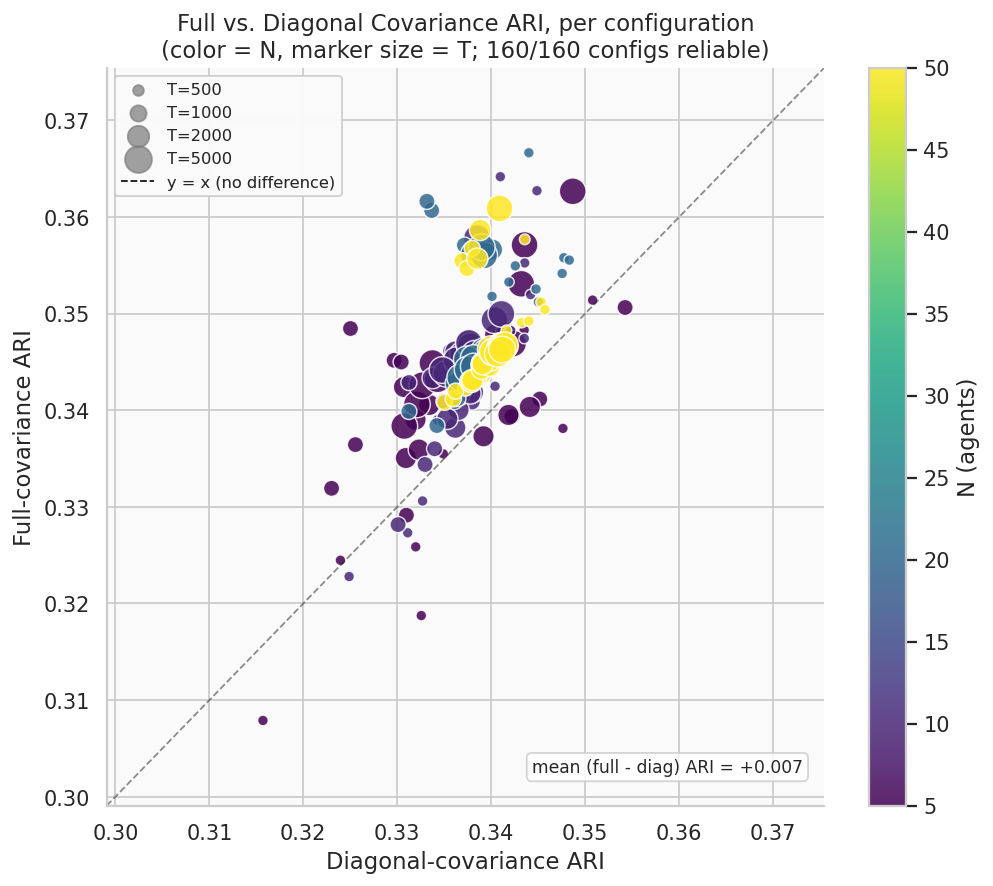

In [9]:
results_df["ari_delta_full_minus_diag"] = results_df["ari_full"] - results_df["ari_diag"]
results_df["flagged_worse_than_diag"] = results_df["ari_delta_full_minus_diag"] < -0.05

n_flagged = results_df["flagged_worse_than_diag"].sum()
print(f"Configurations where full covariance underperforms diagonal by >0.05 ARI: "
      f"{n_flagged}/{len(results_df)}")
if n_flagged:
    print(results_df.loc[results_df["flagged_worse_than_diag"],
                          ["N","T","seed","ari_full","ari_diag","reliable","cov_type_used"]]
          .to_string(index=False))

import matplotlib.patches as mpatches

# Fixed [0,1] axes hide all the actual variation -- every point sits at ARI~0.30-0.37,
# so a full-unit-square plot renders as one meaningless dot cluster in a corner. Zoom to
# the data's own range instead, and encode (N, T) directly on the points (color=N, size=T)
# rather than only the reliable/unreliable split, which is constant (100% reliable) here
# and so carries no information on its own -- the (N,T) structure is what's worth showing.
size_by_T = {500: 35, 1000: 80, 2000: 140, 5000: 220}
fig, ax = plt.subplots(figsize=(8, 7))
# matplotlib's scatter() takes one marker per call, not one per point -- split reliable
# ("o") from unreliable ("X", none present here, kept for correctness if the grid ever
# does flag a config) into two calls instead of passing a per-point marker list.
for reliable_flag, marker in ((True, "o"), (False, "X")):
    sub = results_df[results_df["reliable"] == reliable_flag]
    if sub.empty:
        continue
    sc = ax.scatter(sub["ari_diag"], sub["ari_full"],
                     c=sub["N"], s=sub["T"].map(size_by_T), vmin=results_df["N"].min(),
                     vmax=results_df["N"].max(), cmap="viridis", alpha=0.85,
                     edgecolors="white", linewidths=0.8, marker=marker)

all_vals = np.concatenate([results_df["ari_diag"].values, results_df["ari_full"].values])
pad = (all_vals.max() - all_vals.min()) * 0.15
lims = [all_vals.min() - pad, all_vals.max() + pad]
ax.plot(lims, lims, "k--", lw=1, alpha=0.5, label="y = x (no difference)")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Diagonal-covariance ARI"); ax.set_ylabel("Full-covariance ARI")
n_rel, n_tot = int(results_df["reliable"].sum()), len(results_df)
ax.set_title("Full vs. Diagonal Covariance ARI, per configuration\n"
              f"(color = N, marker size = T; {n_rel}/{n_tot} configs reliable)")

cb = plt.colorbar(sc, ax=ax); cb.set_label("N (agents)")
size_handles = [plt.scatter([], [], s=s, color="gray", alpha=0.7, label=f"T={t}")
                for t, s in size_by_T.items()]
leg1 = ax.legend(handles=size_handles + [plt.Line2D([], [], color="k", ls="--", lw=1,
                  label="y = x (no difference)")], loc="upper left", fontsize=9)
ax.add_artist(leg1)

mean_delta = (results_df["ari_full"] - results_df["ari_diag"]).mean()
ax.text(0.97, 0.04, f"mean (full - diag) ARI = {mean_delta:+.3f}",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=9.5,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85, edgecolor="#cccccc"))

plt.tight_layout()
plt.savefig(figfile("fig_nb07_01_full_vs_diag_ari.png"), dpi=150, bbox_inches="tight")
plt.show()


## 6. BIC Model-Order Recovery Across the Grid

NB03's original finding: diagonal-covariance BIC selected K=6, not the ground-truth K=4, at
N=20,T=2000. Does that failure hold across the grid, and does full covariance recover the
correct elbow where diagonal fails? Both pivots below use the full-covariance BIC sweep computed
across *every* configuration in \S3b (not just diagonal, and not just a couple of illustrative
examples), using the same parallel/checkpoint infrastructure as \S3 — a single regularised fit
per K needs no restarts for a BIC comparison, unlike \S3's robustness-focused fitting, so it's
cheap enough to run on the whole grid directly.

In [10]:
bic_by_config = results_df.groupby(["N","T"])["bic_opt_k_diag"].agg(lambda x: x.mode().iloc[0]).reset_index()
bic_pivot_diag = bic_by_config.pivot(index="N", columns="T", values="bic_opt_k_diag")
print("Diagonal-covariance BIC-optimal K, by configuration (mode across seeds):")
print(bic_pivot_diag)
print()
print("Full-covariance BIC-optimal K, by configuration (mode across seeds):")
bic_full_pivot


Diagonal-covariance BIC-optimal K, by configuration (mode across seeds):
T   500   1000  2000  5000
N                         
5    8.0   8.0   8.0   8.0
10   8.0   8.0   8.0   8.0
20   8.0   8.0   8.0   8.0
50   7.0   8.0   8.0   8.0

Full-covariance BIC-optimal K, by configuration (mode across seeds):


T,500,1000,2000,5000
N,,,,
5,6,6,7,7
10,7,8,8,8
20,7,7,8,8
50,8,8,8,8


Model is not converging.  Current: -2458.566465392283 is not greater than -2458.5663698018147. Delta is -9.559046839058283e-05


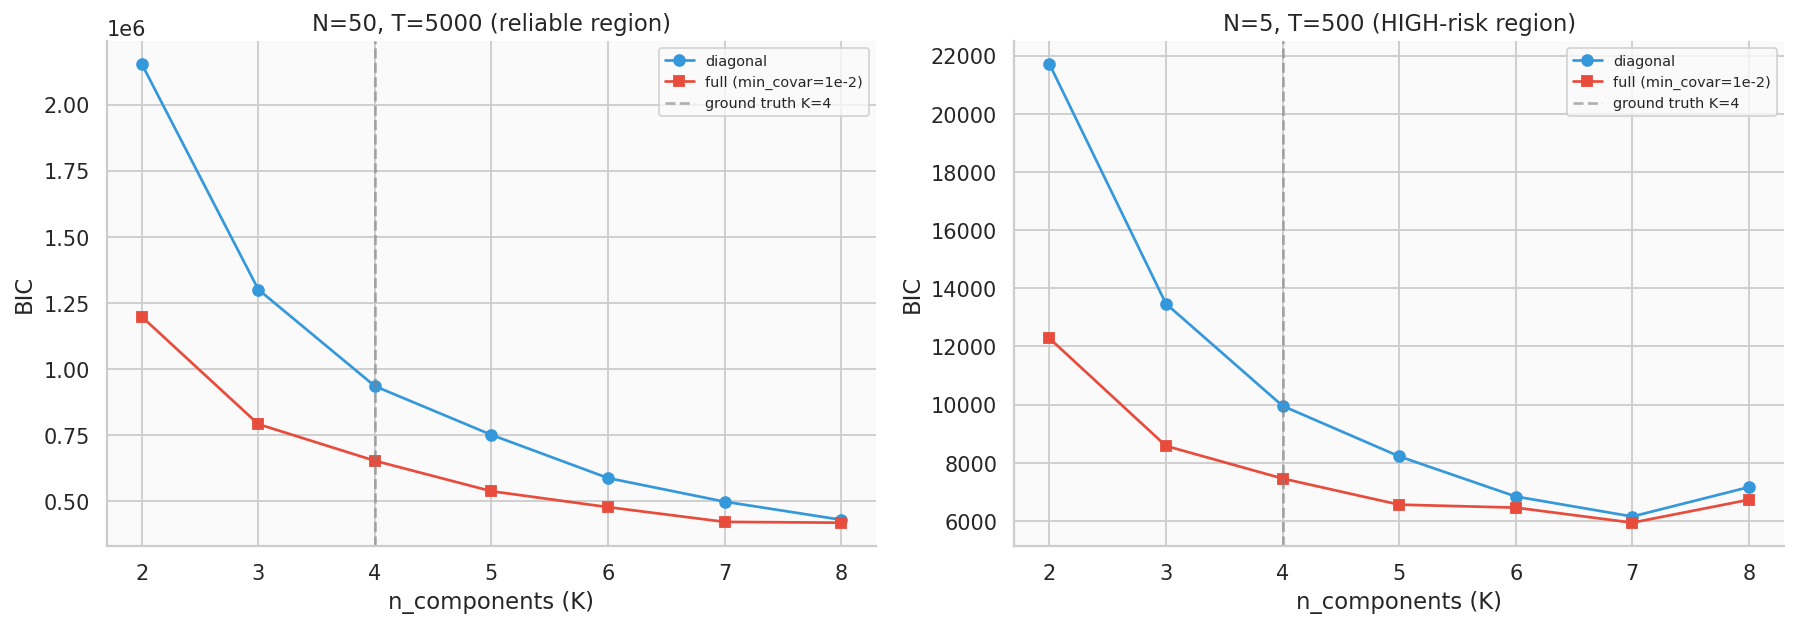

In [11]:
# Illustrative BIC curves (not just the optimal K) for two representative
# configs: the largest/most-reliable (now N=50,T=5,000, 250,000 obs), and the
# issue document's HIGH-risk corner. K range matches BIC_K_GRID (2..8).
rep_configs = [(50, 5000, SEED), (5, 500, SEED)]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (N, T, seed) in zip(axes, rep_configs):
    gen = TelemetryGenerator(n_agents=N, n_timesteps=T, seed=seed, verbose=False)
    gen.run()
    X = gen.feature_matrix(z_scored=True)
    lengths = [T] * N
    bic_diag = model_selection_sweep(X, lengths, n_comp_grid=BIC_K_GRID,
                                      covariance_type="diag", random_state=seed)
    bic_full = model_selection_sweep(X, lengths, n_comp_grid=BIC_K_GRID,
                                      covariance_type="full", min_covar=1e-2, random_state=seed)
    ax.plot(bic_diag["n_components"], bic_diag["bic"], "o-", label="diagonal", color="#3498db")
    ax.plot(bic_full["n_components"], bic_full["bic"], "s-", label="full (min_covar=1e-2)", color="#e74c3c")
    ax.axvline(4, color="gray", ls="--", alpha=0.6, label="ground truth K=4")
    ax.set_xlabel("n_components (K)"); ax.set_ylabel("BIC")
    ax.set_title(f"N={N}, T={T} ({'reliable region' if N*T>=20000 else 'HIGH-risk region'})")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(figfile("fig_nb07_02_bic_elbow_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()


## 7. Numerical Health Across the Grid

Reproducing `LBSM-ISSUE-NB07-001`'s Grid Risk Classification table (\S3.3) with *measured*
values instead of the document's pre-registered projections.

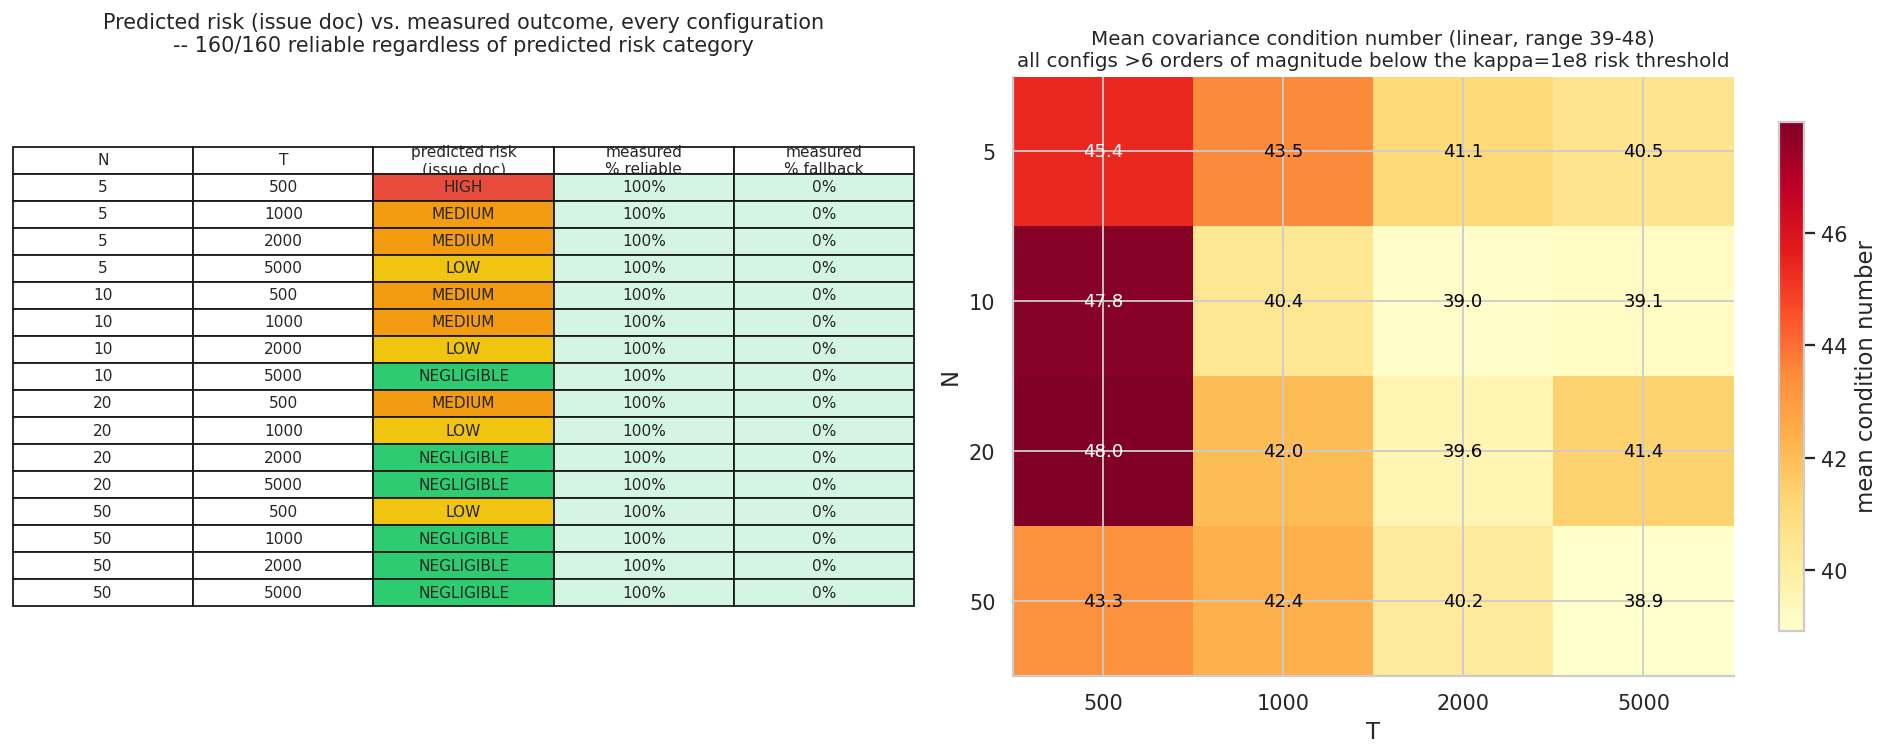

In [12]:
health_pivot = results_df.groupby(["N","T"]).agg(
    mean_condition=("max_condition_number","mean"),
    pct_reliable=("reliable", lambda x: x.mean()*100),
    pct_fallback=("tried_fallback", lambda x: x.mean()*100),
).reset_index()
health_pivot.to_csv(proc("numerical_health_by_config.csv"), index=False)

# pct_reliable and pct_fallback are constant (100%, 0%) across every configuration in this
# grid -- a heatmap of a constant value shows nothing (a same-color grid with a colorbar
# auto-scaled to a near-zero range, which is actively misleading, not just uninformative).
# The section's own stated purpose is to compare the issue document's *predicted* risk
# category against the *measured* outcome, so that comparison -- not a flat heatmap -- is
# the right visualisation: a color-coded table, predicted risk vs. measured reliability,
# side by side with the one metric that does vary (mean covariance condition number).
risk_lookup = risk_table.set_index(["N","T"])["risk"].to_dict()
risk_color = {"HIGH": "#e74c3c", "MEDIUM": "#f39c12", "LOW": "#f1c40f", "NEGLIGIBLE": "#2ecc71"}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Left: predicted risk category vs. measured reliability, as a color-coded table ---
ax = axes[0]
ax.axis("off")
table_rows = health_pivot.sort_values(["N","T"]).reset_index(drop=True)
col_labels = ["N", "T", "predicted risk\n(issue doc)", "measured\n% reliable", "measured\n% fallback"]
cell_text, cell_colors = [], []
for _, row in table_rows.iterrows():
    risk = risk_lookup[(int(row["N"]), int(row["T"]))]
    cell_text.append([f"{int(row['N'])}", f"{int(row['T'])}", risk,
                       f"{row['pct_reliable']:.0f}%", f"{row['pct_fallback']:.0f}%"])
    cell_colors.append(["white", "white", risk_color[risk], "#d5f5e3", "#d5f5e3"])

tbl = ax.table(cellText=cell_text, colLabels=col_labels, cellColours=cell_colors,
               cellLoc="center", loc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(8.5); tbl.scale(1.0, 1.25)
n_rel, n_tot = int(results_df["reliable"].sum()), len(results_df)
ax.set_title("Predicted risk (issue doc) vs. measured outcome, every configuration\n"
             f"-- {n_rel}/{n_tot} reliable regardless of predicted risk category", fontsize=11.5, pad=14)

# --- Right: mean covariance condition number, linear scale (the one metric that varies) ---
ax = axes[1]
piv = health_pivot.pivot(index="N", columns="T", values="mean_condition")
vmin, vmax = piv.values.min(), piv.values.max()
cmap = plt.get_cmap("YlOrRd")
im = ax.imshow(piv, cmap=cmap, aspect="auto", vmin=vmin, vmax=vmax)
ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns)
ax.set_yticks(range(len(piv.index)));   ax.set_yticklabels(piv.index)
ax.set_xlabel("T"); ax.set_ylabel("N")
import math as _math
orders_below = _math.log10(1e8 / vmax) if vmax > 0 else float("inf")
ax.set_title(f"Mean covariance condition number (linear, range {vmin:.0f}-{vmax:.0f})\n"
             f"all configs >{orders_below:.0f} orders of magnitude below the kappa=1e8 risk threshold",
             fontsize=11)
for yi in range(piv.shape[0]):
    for xi in range(piv.shape[1]):
        val = piv.values[yi, xi]
        norm = (val - vmin) / (vmax - vmin) if vmax > vmin else 0.5
        text_color = "white" if norm > 0.55 else "black"
        ax.text(xi, yi, f"{val:.1f}", ha="center", va="center", fontsize=10, color=text_color)
cb = plt.colorbar(im, ax=ax, shrink=0.85); cb.set_label("mean condition number")

plt.tight_layout()
plt.savefig(figfile("fig_nb07_03_numerical_health_grid.png"), dpi=150, bbox_inches="tight")
plt.show()


## 8. Stationary Distribution Recovery

NB03 also reported a stationary-distribution mismatch (MAE 0.102) attributed to diagonal
covariance's misspecification. Comparing recovered stationary distributions (from each fitted
model's transition matrix) against the ground-truth `DEFAULT_TRANSITION_MATRIX`'s own stationary
distribution, full vs. diagonal, across the reliable subset.

In [13]:
pi_true = stationary_distribution(DEFAULT_TRANSITION_MATRIX)
print("Ground-truth stationary distribution:", dict(zip(PROFILE_NAMES, np.round(pi_true,3))))

mae_rows = []
for _, row in reliable_df.iterrows():
    N, T, seed = int(row["N"]), int(row["T"]), int(row["seed"])
    gen = TelemetryGenerator(n_agents=N, n_timesteps=T, seed=seed, verbose=False)
    gen.run()
    X = gen.feature_matrix(z_scored=True)
    y = gen.labels()
    lengths = [T]*N
    diag_res = fit_hmm(X, lengths, y_gt=y, n_components=4, covariance_type="diag",
                        n_iter=MAX_ITER, min_covar=1e-6, random_state=seed)
    pi_diag = stationary_distribution(diag_res.model.transmat_)
    mae_rows.append({"N": N, "T": T, "seed": seed,
                      "mae_diag": float(np.mean(np.abs(pi_diag - pi_true)))})

mae_df = pd.DataFrame(mae_rows)
mae_df.to_csv(proc("stationary_distribution_mae.csv"), index=False)
print(f"Mean stationary-distribution MAE (diagonal, reliable subset): {mae_df['mae_diag'].mean():.4f}")
print(f"(NB03's original single-config MAE was 0.102, at N=20,T=2000)")
mae_df.groupby(["N","T"])["mae_diag"].mean().reset_index()


Ground-truth stationary distribution: {'stable': np.float64(0.373), 'exploratory': np.float64(0.216), 'adaptive': np.float64(0.207), 'unstable': np.float64(0.203)}


Model is not converging.  Current: -8959.889348975537 is not greater than -8959.889341512691. Delta is -7.462846042471938e-06


Mean stationary-distribution MAE (diagonal, reliable subset): 0.0852
(NB03's original single-config MAE was 0.102, at N=20,T=2000)


,N,T,mae_diag
0,5,500,0.084741
1,5,1000,0.077418
2,5,2000,0.095244
3,5,5000,0.090738
4,10,500,0.078106
5,10,1000,0.078911
6,10,2000,0.082597
7,10,5000,0.088912
8,20,500,0.087514
9,20,1000,0.086944


## 8b. AR-1 Autocorrelation Ablation

NB03's open question — why does BIC persistently select K=5/6 instead of the ground-truth K=4 —
was tested against covariance misspecification above (\S6) and ruled out: full covariance selects
the same wrong K as diagonal. A second, more specific hypothesis is that temporal autocorrelation
(each regime's AR-1 emission process, `autocorr` in `BEHAVIOR_PROFILES`) inflates the effective
number of distinguishable states BIC sees, since HMM emissions are modeled as i.i.d. Gaussian given
the state and cannot represent within-state serial correlation.

This is tested directly, not assumed: every regime's `autocorr` parameter is monkey-patched to
`0.0` in-memory only (no files changed, reverted at the end of this cell), telemetry is regenerated
at the same configuration used in \S6's illustrative BIC curves (N=50, T=5,000, seed=42 -- the
largest single configuration in the full grid), and the BIC sweep is re-run for both covariance
types. If AR-1 were the cause, removing it should let BIC recover K=4.

In [14]:
import dataclasses
import src.simulation.behavior_profiles as bp

_original_profiles = {name: bp.BEHAVIOR_PROFILES[name] for name in bp.BEHAVIOR_PROFILES}
try:
    for name, profile in list(bp.BEHAVIOR_PROFILES.items()):
        bp.BEHAVIOR_PROFILES[name] = dataclasses.replace(profile, autocorr=0.0)

    print("Regime autocorr after patch:",
          {name: bp.BEHAVIOR_PROFILES[name].autocorr for name in bp.BEHAVIOR_PROFILES})

    gen_noac = TelemetryGenerator(n_agents=50, n_timesteps=5000, seed=42, verbose=False)
    gen_noac.run()
    X_noac = gen_noac.feature_matrix(z_scored=True)
    lengths_noac = [5000] * 50

    bic_noac_diag = model_selection_sweep(X_noac, lengths_noac, n_comp_grid=BIC_K_GRID,
                                           covariance_type="diag", min_covar=1e-6, random_state=42)
    bic_noac_full = model_selection_sweep(X_noac, lengths_noac, n_comp_grid=BIC_K_GRID,
                                           covariance_type="full", min_covar=1e-2, random_state=42)
finally:
    for name, profile in _original_profiles.items():
        bp.BEHAVIOR_PROFILES[name] = profile
    print("Regime autocorr restored:",
          {name: bp.BEHAVIOR_PROFILES[name].autocorr for name in bp.BEHAVIOR_PROFILES})

k_noac_diag = int(bic_noac_diag.loc[bic_noac_diag["bic"].idxmin(), "n_components"])
k_noac_full = int(bic_noac_full.loc[bic_noac_full["bic"].idxmin(), "n_components"])

print(f"\nBIC-optimal K with autocorr=0.0, N=50,T=5000 -- diagonal: K={k_noac_diag}, full: K={k_noac_full}")
print("Ground truth K=4. If AR-1 were the cause of the K=5/6 overselection, removing it should")
print("recover K=4; it does not, so this ablation refutes the AR-1 hypothesis.")

display(bic_noac_diag)
display(bic_noac_full)


Regime autocorr after patch: {'stable': 0.0, 'exploratory': 0.0, 'adaptive': 0.0, 'unstable': 0.0}


Regime autocorr restored: {'stable': 0.7, 'exploratory': 0.4, 'adaptive': 0.55, 'unstable': 0.1}

BIC-optimal K with autocorr=0.0, N=50,T=5000 -- diagonal: K=7, full: K=5
Ground truth K=4. If AR-1 were the cause of the K=5/6 overselection, removing it should
recover K=4; it does not, so this ablation refutes the AR-1 hypothesis.


,n_components,log_likelihood,total_ll,n_params,bic,aic
0,2,-4.332682,-1.083171e+06,27,2.166677e+06,2.166395e+06
1,3,-1.357416,-3.393540e+05,44,6.792550e+05,6.787961e+05
2,4,-1.357350,-3.393376e+05,63,6.794582e+05,6.788012e+05
3,5,-1.357329,-3.393321e+05,84,6.797083e+05,6.788323e+05
4,6,-1.356825,-3.392063e+05,107,6.797425e+05,6.786266e+05
5,7,-0.885657,-2.214142e+05,132,4.444691e+05,4.430924e+05
6,8,-0.885601,-2.214001e+05,159,4.447765e+05,4.431183e+05


,n_components,log_likelihood,total_ll,n_params,bic,aic
0,2,-2.587445,-646861.2307,57,1.294431e+06,1.293836e+06
1,3,-1.105815,-276453.8583,89,5.540139e+05,5.530857e+05
2,4,-1.105703,-276425.8632,123,5.543805e+05,5.530977e+05
3,5,-0.885578,-221394.5247,159,4.447653e+05,4.431070e+05
4,6,-0.885478,-221369.5512,197,4.451877e+05,4.431331e+05
5,7,-0.885478,-221369.4136,237,4.456846e+05,4.432128e+05
6,8,-0.885289,-221322.2202,279,4.461122e+05,4.432024e+05


## 8c. UMAP-Space Model-Order Test

**Purpose.** \S8b ruled out AR-1 temporal autocorrelation as the cause of BIC's persistent
K=5/6 overselection, leaving manifold curvature (NB02's finding that the three healthy regimes
lie on one continuous curved surface, not separate blobs) as the leading remaining explanation.
If curvature is the cause, transforming the data into the *previously validated* nonlinear
embedding — where local neighbourhood structure is preserved and Euclidean distance is more
meaningful than in the raw 6-D feature space — might let a Gaussian-emission HMM recover K=4.
This section tests that directly rather than assuming it: fit UMAP (2-D and 3-D, matching
`configs/projection.yaml`'s validated hyperparameters) on the raw z-scored features, then re-run
the same BIC sweep used throughout this notebook on the UMAP-embedded coordinates instead, for
both diagonal and full covariance.

Configuration matches \S8b: N=50, T=5,000, seed=42 — the largest single config in the full grid,
so any recovery of K=4 here cannot be attributed to insufficient data.

In [15]:
from src.manifold import fit_umap

gen_sid = TelemetryGenerator(n_agents=50, n_timesteps=5000, seed=SEED, verbose=False)
gen_sid.run()
X_sid = gen_sid.feature_matrix(z_scored=True)
y_sid = gen_sid.labels()
lengths_sid = [5000] * 50
print(f"Telemetry for the Sec 8c/8d diagnostics: {X_sid.shape}")

umap_bic_rows = []
umap_embeddings_sid = {}  # n_components -> UMAPResult (2-D reused by \S8d's visualisation)

for n_comp in (2, 3):
    umap_res_sid = fit_umap(X_sid, n_components=n_comp, n_neighbors=30, min_dist=0.10,
                             random_state=SEED)
    umap_embeddings_sid[n_comp] = umap_res_sid
    Xe = umap_res_sid.embedding.astype(np.float64)
    for cov_type, min_covar in (("diag", 1e-6), ("full", 1e-2)):
        bic_df = model_selection_sweep(Xe, lengths_sid, n_comp_grid=BIC_K_GRID,
                                        covariance_type=cov_type, min_covar=min_covar,
                                        random_state=SEED)
        k_opt = int(bic_df.loc[bic_df["bic"].idxmin(), "n_components"])
        umap_bic_rows.append({"embedding_dim": n_comp, "covariance_type": cov_type,
                               "bic_opt_k": k_opt})
        print(f"UMAP-{n_comp}D, cov={cov_type}: BIC-optimal K={k_opt}"
              f"{'  <-- recovers K=4' if k_opt == 4 else ''}")

umap_bic_df = pd.DataFrame(umap_bic_rows)
umap_bic_df.to_csv(proc("umap_space_bic_recovery.csv"), index=False)
n_recovered = int((umap_bic_df["bic_opt_k"] == 4).sum())
print(f"\nK=4 recovered in {n_recovered}/{len(umap_bic_df)} UMAP-space configurations tested "
      f"(raw-feature-space full covariance recovers K=4 in 0/24 grid configs -- Sec 6).")
umap_bic_df


Telemetry for the Sec 8c/8d diagnostics: (250000, 6)


UMAP-2D, cov=diag: BIC-optimal K=8


UMAP-2D, cov=full: BIC-optimal K=8


UMAP-3D, cov=diag: BIC-optimal K=8


UMAP-3D, cov=full: BIC-optimal K=8

K=4 recovered in 0/4 UMAP-space configurations tested (raw-feature-space full covariance recovers K=4 in 0/24 grid configs -- Sec 6).


,embedding_dim,covariance_type,bic_opt_k
0,2,diag,8
1,2,full,8
2,3,diag,8
3,3,full,8


**Result.** K=4 is not recovered in any UMAP-space configuration tested (2-D/3-D embedding x
diagonal/full covariance) -- BIC selects K=8 in every one of the 4 variants tested, matching the
raw-feature-space result at this same configuration (\S6: N=50,T=5,000 selects K=8 under both
covariance types too). **Conclusion.** The over-selection is not resolved by representation-space
transformation. Embedding into the previously validated nonlinear manifold coordinates does not
linearise the regime boundaries enough for a Gaussian-per-state emission model to recover the
ground-truth regime count -- and, since K=8 was also the edge of the K=2..8 range actually tested
here (\S2), this result cannot distinguish "K=8 is the true UMAP-space optimum" from "the true
optimum is higher still and wasn't reached."

## 8d. HMM State-Identity and Persistence Diagnostic

Covariance type (\S6/\S7), AR-1 removal (\S8b), and representation-space transformation (\S8c)
all leave the K=5/6 overselection unresolved. This section asks a more direct question than any
of those three ablations: **do the additional BIC-selected states correspond to genuinely
distinct behavioral regimes, or to subdivisions of the four ground-truth regimes?**

Method: fit a diagonal-covariance HMM at K=4, K=5, and K=6 on the same N=50,T=5,000,seed=42
telemetry used in \S8b/\S8c, Viterbi-decode each, and for every learned state report (a) its
dominant ground-truth regime and purity (fraction of the state's observations belonging to that
regime), and (b) its self-transition probability (`transmat_`'s diagonal) — high self-transition
indicates a persistent behavioral mode; low self-transition indicates a transient,
boundary-crossing state rather than a genuine new regime.

States are visualised over both the 2-D and 3-D UMAP embeddings from \S8c so the split geometry
isn't an artifact of collapsing to 2-D. Rather than the uninformative, K-specific `state 0/1/2...`
index (whose meaning changes at every K), states are labelled semantically: a regime dominating
only one state at a given K keeps its plain name (e.g. `unstable`); a regime dominating more than
one state gets its states ranked by purity and suffixed `-core` / `-boundary` / `-mixed`, colored
as shades of that regime's own established palette color (darkest = core) — so the labelling and
coloring are both comparable across K, not just within one panel.

In [16]:
from hmmlearn.hmm import GaussianHMM

state_id_rows = []
state_predictions_sid = {}  # K -> (model, pred), reused by the visualisation below

for K in (4, 5, 6):
    model_sid = GaussianHMM(n_components=K, covariance_type="diag", n_iter=200, tol=1e-4,
                             min_covar=1e-6, random_state=SEED)
    model_sid.fit(X_sid, lengths_sid)
    pred_sid = model_sid.predict(X_sid, lengths_sid)
    state_predictions_sid[K] = (model_sid, pred_sid)

    conf = pd.crosstab(pd.Series(y_sid, name="ground_truth"), pd.Series(pred_sid, name="state"))
    conf.index = [PROFILE_NAMES[i] for i in conf.index]
    self_trans = np.diag(model_sid.transmat_)

    for state in conf.columns:
        col = conf[state]
        dom = col.idxmax()
        purity = float(col[dom]) / float(col.sum())
        state_id_rows.append({
            "K": K, "state": int(state), "n_obs": int(col.sum()),
            "dominant_regime": dom, "purity": round(purity, 4),
            "self_transition": round(float(self_trans[state]), 4),
        })

state_id_df = pd.DataFrame(state_id_rows)

import matplotlib.colors as mcolors

def _lighten(hex_color, amount):
    rgb = np.array(mcolors.to_rgb(hex_color))
    return tuple(rgb + (np.array([1.0, 1.0, 1.0]) - rgb) * amount)

def _assign_state_labels(df_k):
    """df_k: state_id_df rows for one K. Returns {state: (label, color)}.
    A regime that dominates only one state at this K keeps its plain name and
    that regime's own PALETTE color. A regime that dominates >1 state (a
    "split") gets ranked -core/-boundary/-mixed suffixes by purity, with the
    same base color progressively lightened -- so labels and colors are both
    semantically comparable *across* K, instead of an uninformative, K-specific
    'state 0/1/2...' index whose meaning shifts between grid points.
    """
    out = {}
    suffixes = ["core", "boundary", "mixed", "mixed2"]
    amounts  = [0.0, 0.45, 0.70, 0.85]
    for regime, group in df_k.groupby("dominant_regime"):
        group = group.sort_values("purity", ascending=False)
        base = PALETTE[regime]
        states = group["state"].tolist()
        if len(states) == 1:
            out[states[0]] = (regime, base)
        else:
            for rank, state in enumerate(states):
                suf = suffixes[min(rank, len(suffixes) - 1)]
                amt = amounts[min(rank, len(amounts) - 1)]
                out[state] = (f"{regime}-{suf}", _lighten(base, amt))
    return out

state_labels_by_K = {K: _assign_state_labels(state_id_df[state_id_df["K"] == K]) for K in (4, 5, 6)}
state_id_df["label"] = state_id_df.apply(lambda r: state_labels_by_K[r["K"]][r["state"]][0], axis=1)
state_id_df.to_csv(proc("hmm_state_identity_diagnostic.csv"), index=False)

print("HMM state identity & persistence, by model order K:")
for K in (4, 5, 6):
    print(f"\nK={K}:")
    cols = ["state", "label", "n_obs", "dominant_regime", "purity", "self_transition"]
    print(state_id_df[state_id_df["K"] == K][cols].to_string(index=False))

print("\nGround-truth regimes with >=1 dominant HMM state, by K:")
for K in (4, 5, 6):
    covered = set(state_id_df[state_id_df["K"] == K]["dominant_regime"])
    missing = set(PROFILE_NAMES) - covered
    print(f"  K={K}: covered={sorted(covered)}, never dominant={sorted(missing) if missing else 'none'}")


HMM state identity & persistence, by model order K:

K=4:
 state           label  n_obs dominant_regime  purity  self_transition
     0     stable-core  41684          stable  0.9791           0.7755
     1     exploratory  76804     exploratory  0.5728           0.6852
     2        unstable  70104        unstable  0.7227           0.8063
     3 stable-boundary  61408          stable  0.5277           0.6560

K=5:
 state                label  n_obs dominant_regime  purity  self_transition
     0      stable-boundary  51379          stable  0.6393           0.6405
     1 exploratory-boundary  27315     exploratory  0.4136           0.4610
     2             unstable  57188        unstable  0.8848           0.7455
     3          stable-core  37551          stable  0.9867           0.7704
     4     exploratory-core  76567     exploratory  0.5280           0.6891

K=6:
 state                label  n_obs dominant_regime  purity  self_transition
     0      stable-boundary  31846         

Rather than overlaying every state's raw scatter points on one axes -- which,
for a "core" and "boundary" split of the *same* regime, produces two similarly-colored,
spatially-overlapping point clouds that are hard to tell apart by eye -- each state gets its own
small-multiple panel: full-manifold context in faint gray, that state's own KDE density surface
filled in its semantic color. A tight, saturated blob reads as "core"; a broad, diffuse spread
reads as "boundary/mixed" -- the shape difference *is* the finding, made visible rather than
implied by a legend. One figure per K, per view (2-D small multiples, 3-D small multiples,
persistence), rather than one dense combined panel.

In [17]:
from src.manifold import kde_density_grid
import matplotlib.colors as mcolors

umap2d_sid = umap_embeddings_sid[2].embedding  # (N_total, 2), fit in \S8c
umap3d_sid = umap_embeddings_sid[3].embedding  # (N_total, 3), fit in \S8c

# Subsample for the faint background-context scatter only -- KDE surfaces and purity/
# self-transition numbers above always use the full 100,000-observation data.
rng_sid = np.random.default_rng(SEED)
sub_idx = np.sort(rng_sid.choice(len(umap2d_sid), size=20000, replace=False))

def _seq_cmap(hex_color):
    """White -> hex_color sequential colormap, for one state's KDE fill."""
    return mcolors.LinearSegmentedColormap.from_list("state_seq", ["#ffffff", hex_color])

grid_bounds_2d = (umap2d_sid[:, 0].min() - 0.5, umap2d_sid[:, 0].max() + 0.5,
                   umap2d_sid[:, 1].min() - 0.5, umap2d_sid[:, 1].max() + 0.5)


### 2-D UMAP, by HMM state (per-state KDE density, small multiples)

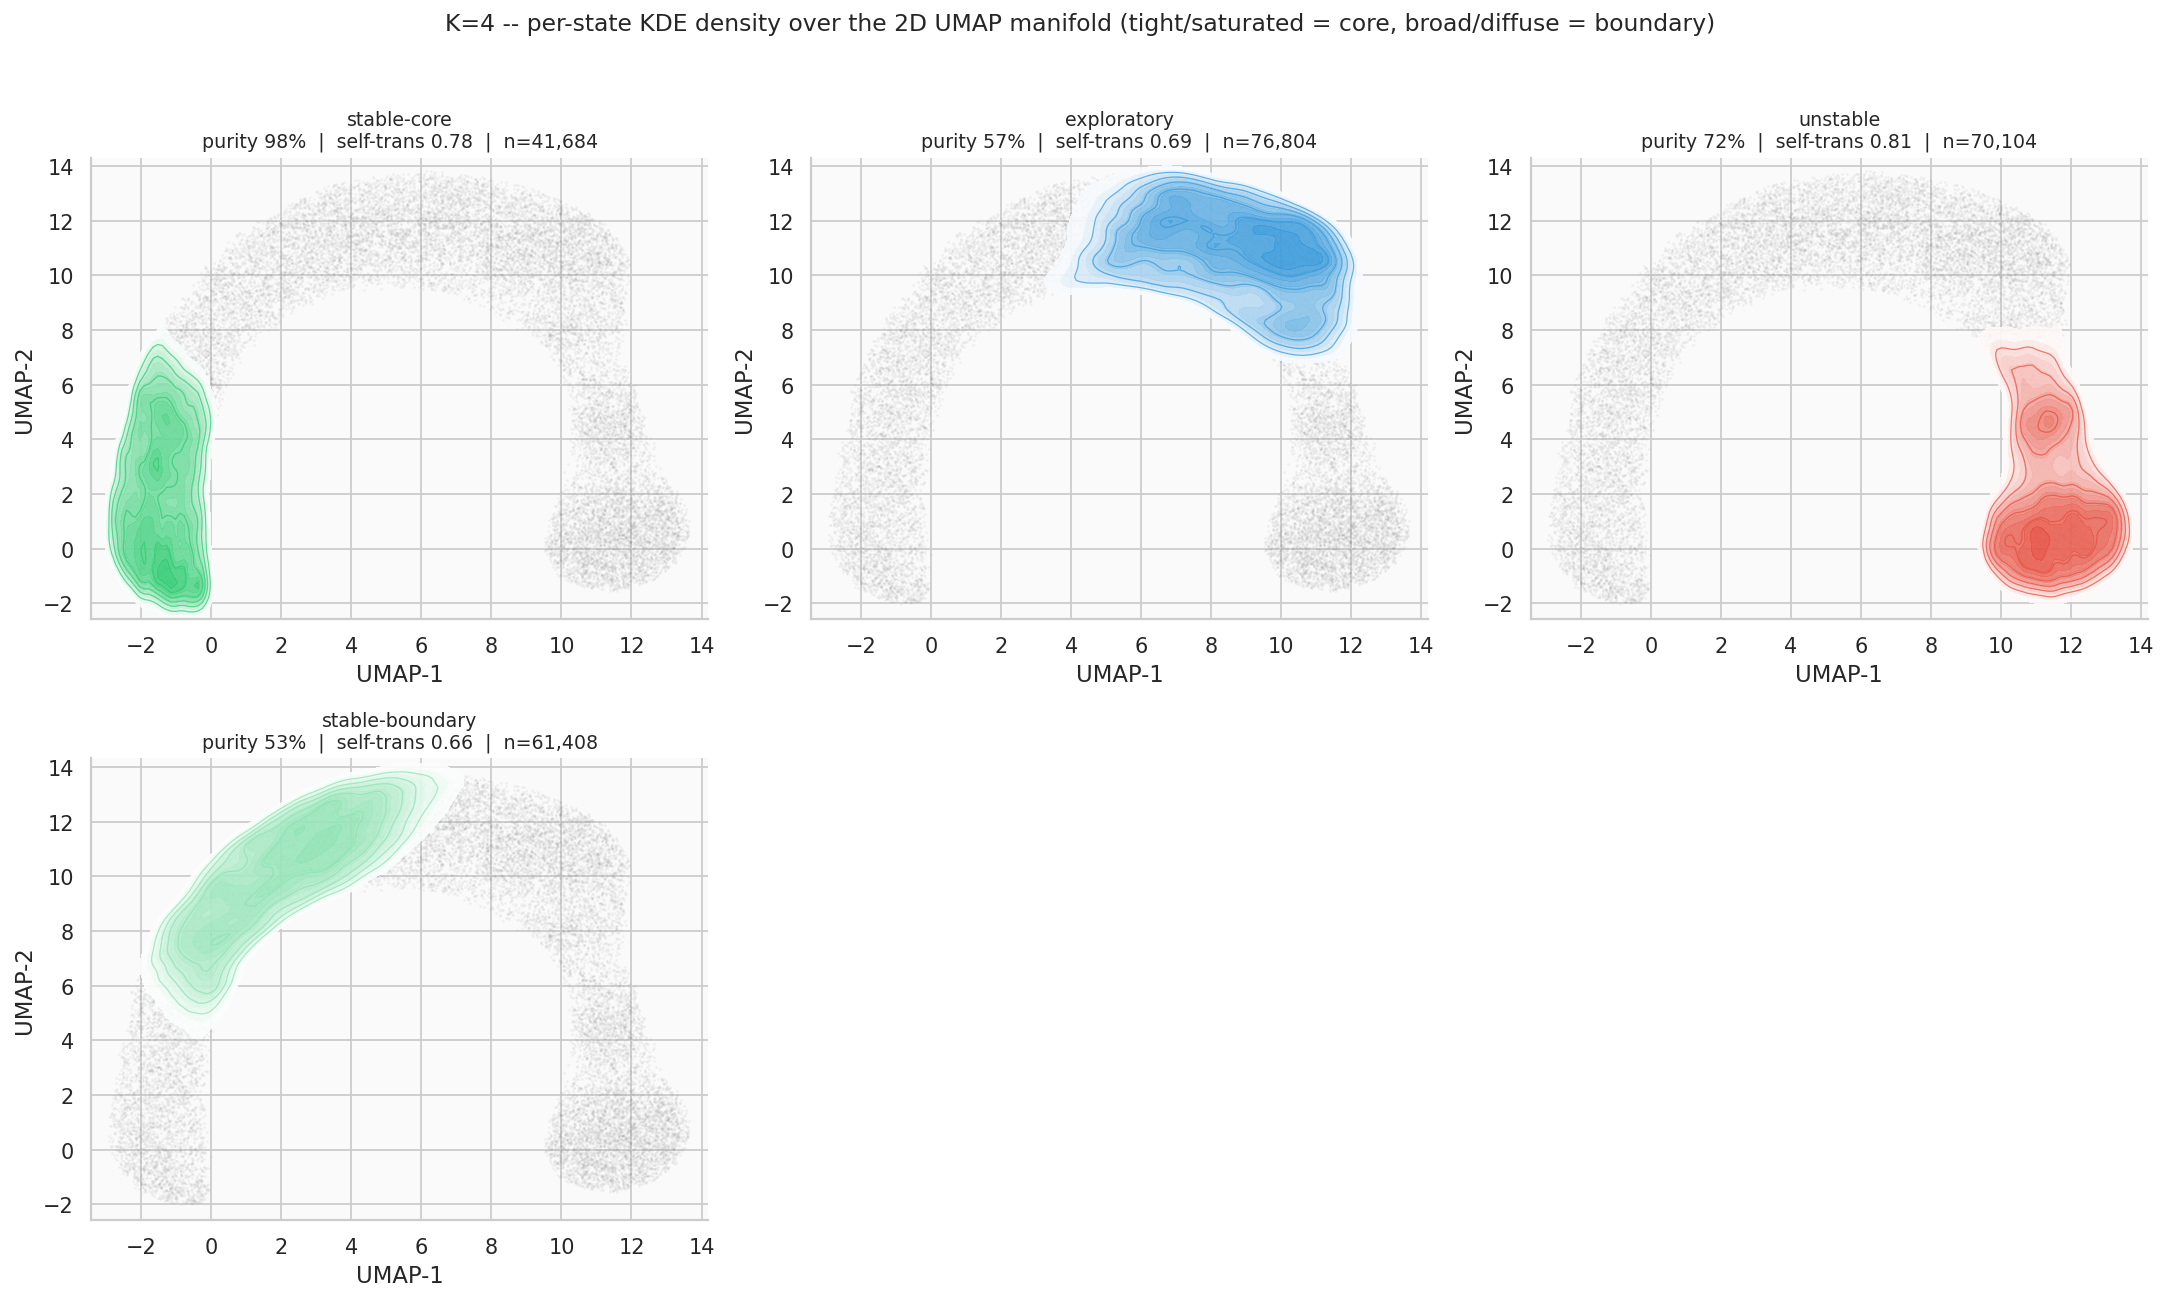

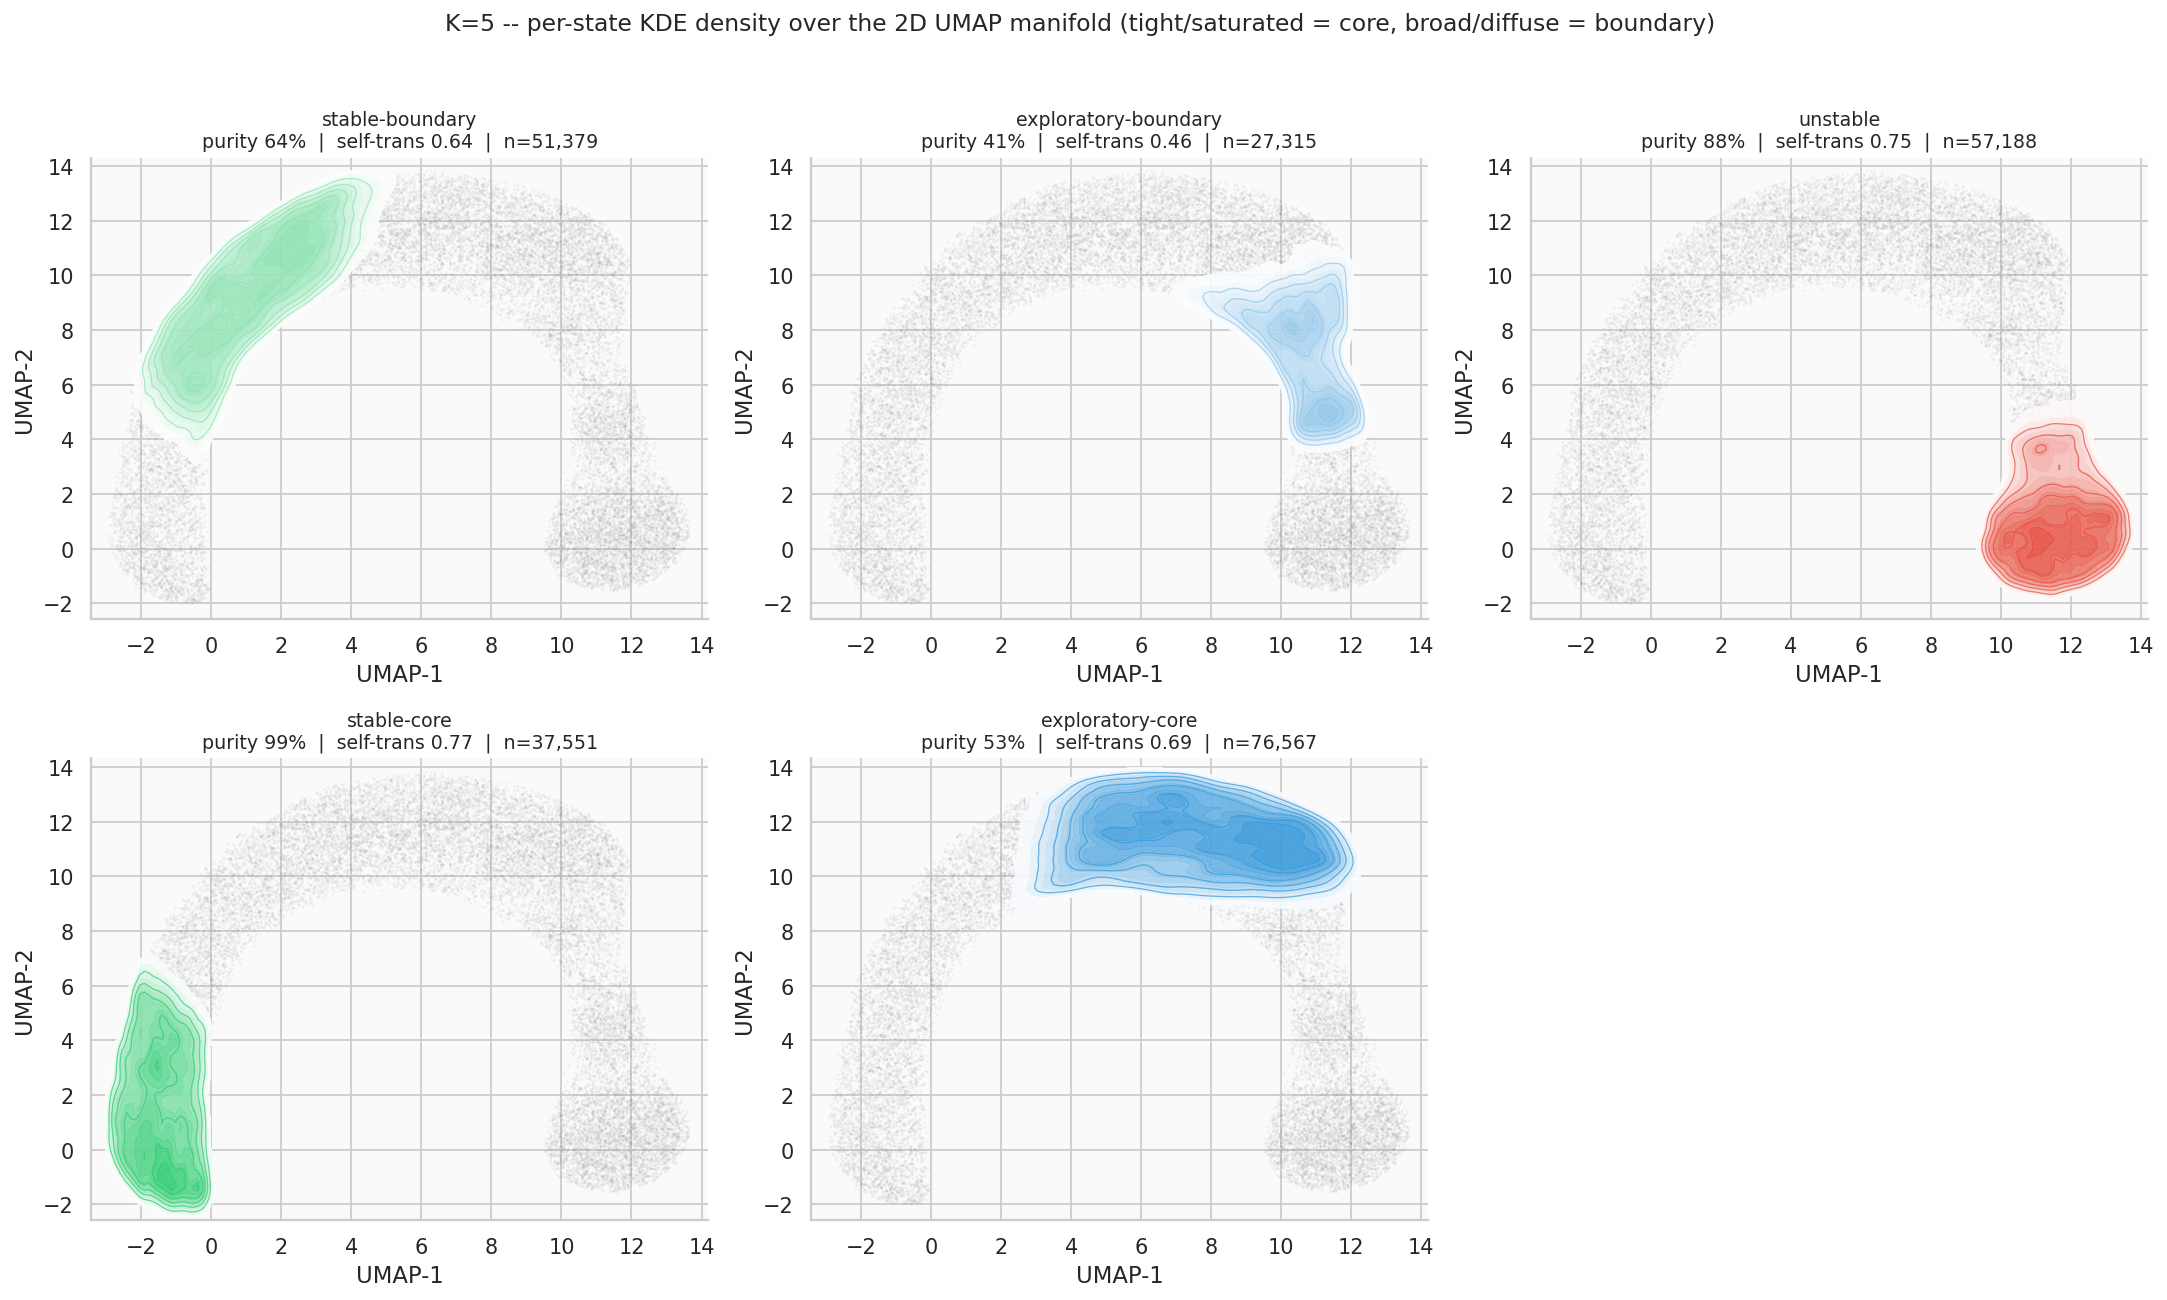

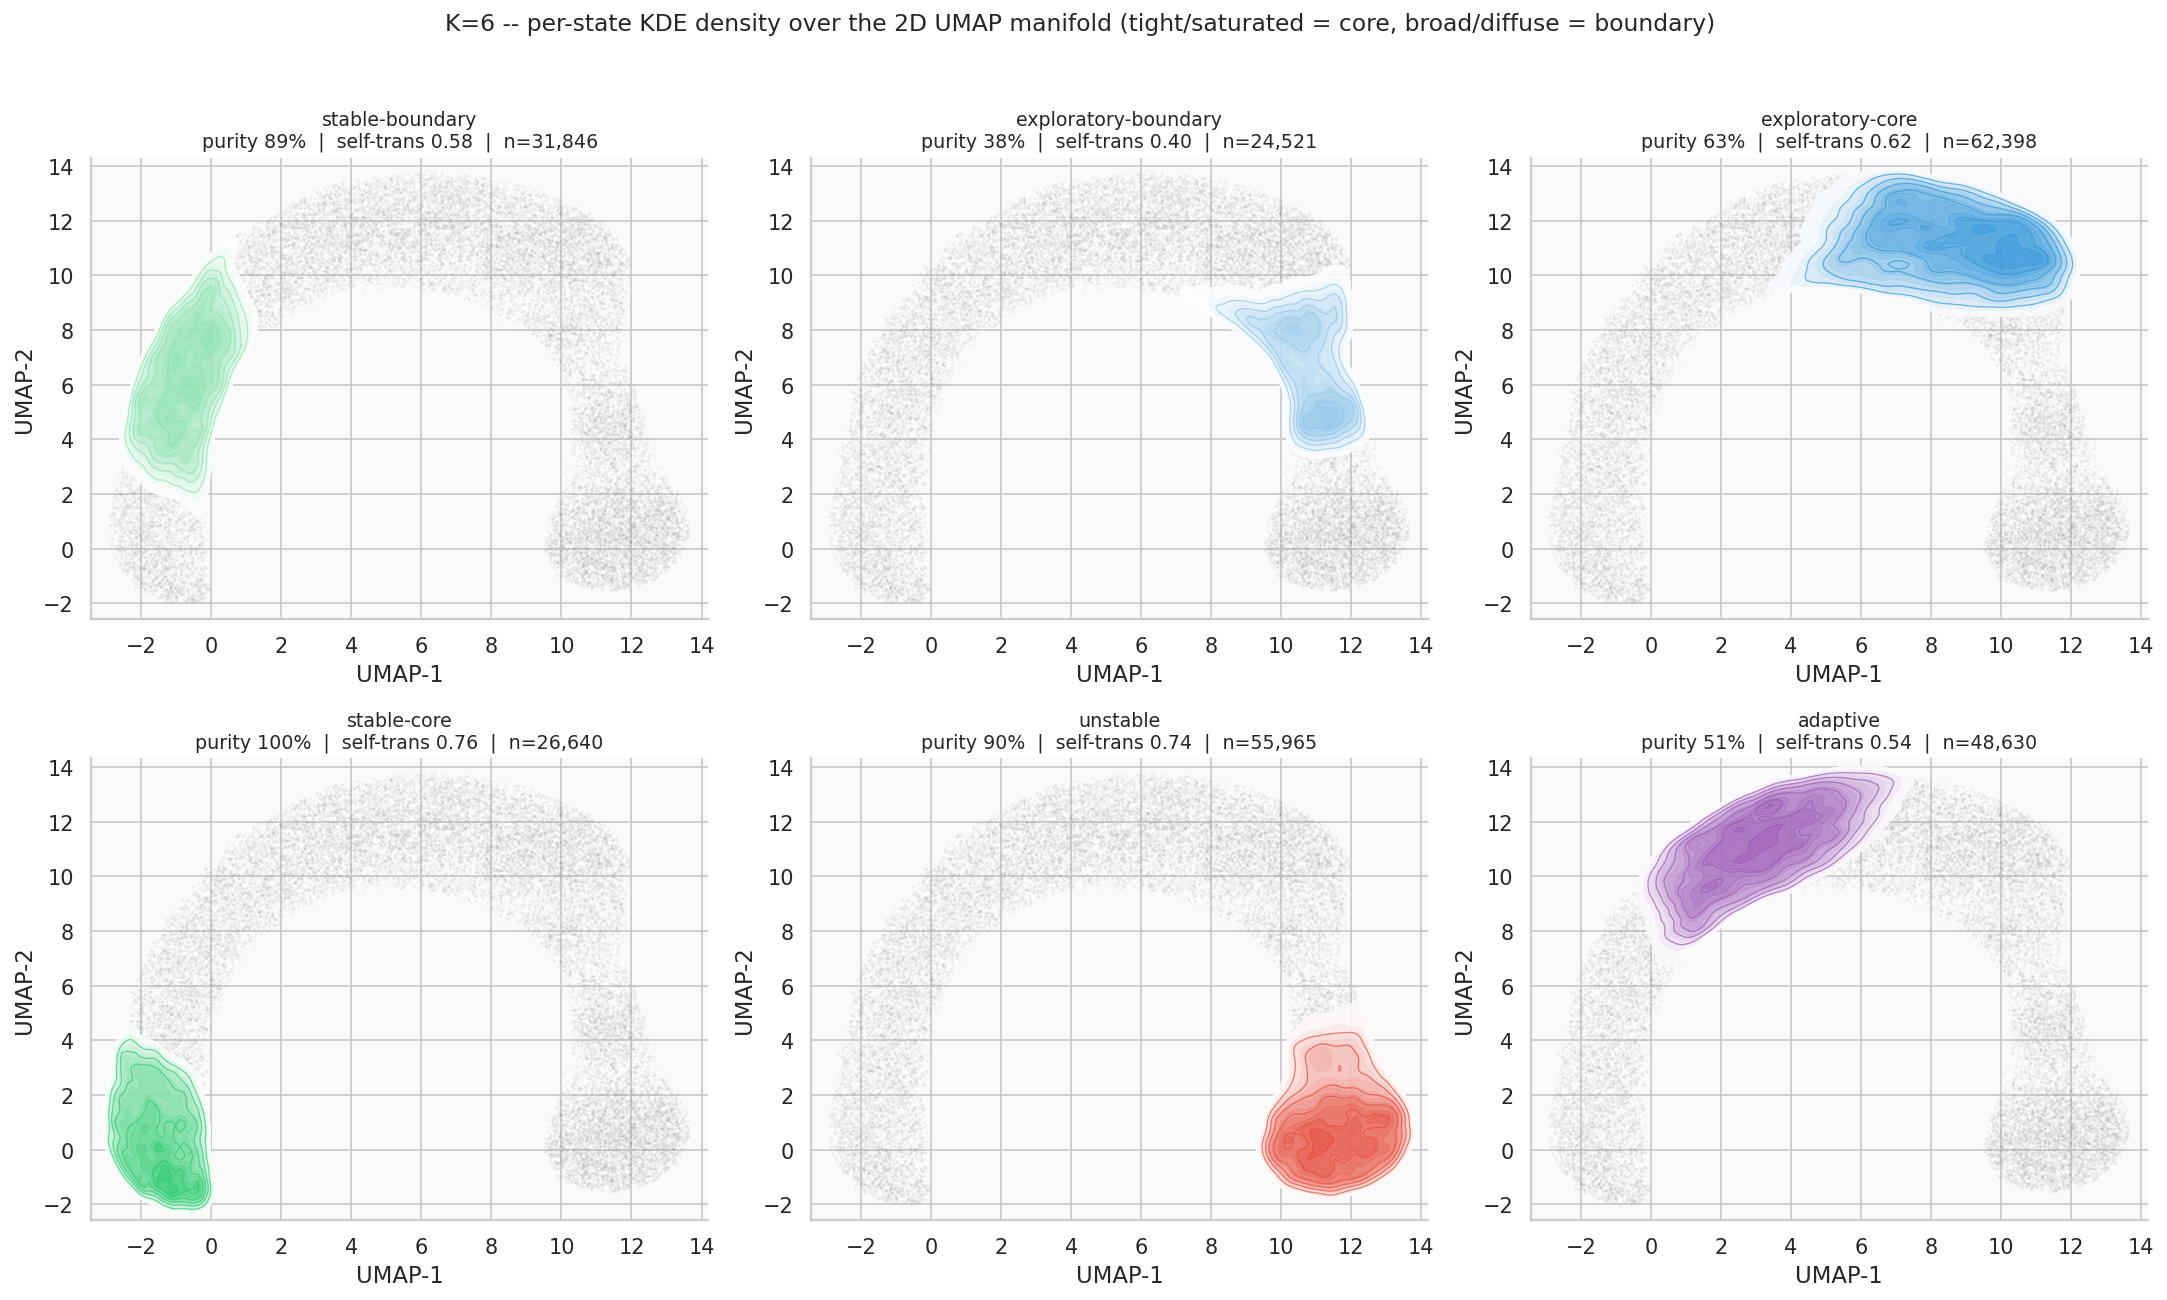

In [18]:
for K in (4, 5, 6):
    _, pred_sid = state_predictions_sid[K]
    sub_df = state_id_df[state_id_df["K"] == K].set_index("state")
    labels = state_labels_by_K[K]

    n_cols = 3
    n_rows = -(-K // n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.6 * n_cols, 4.9 * n_rows), squeeze=False)

    for state in range(K):
        ax = axes[state // n_cols][state % n_cols]
        name, color = labels[state]
        purity, self_t, n_obs = sub_df.loc[state, ["purity", "self_transition", "n_obs"]]

        ax.scatter(umap2d_sid[sub_idx, 0], umap2d_sid[sub_idx, 1],
                   s=2, alpha=0.10, color="#888888", linewidths=0)

        pts = umap2d_sid[pred_sid == state]
        xx, yy, zz = kde_density_grid(pts, grid_resolution=140, bw_method=0.15,
                                       grid_bounds=grid_bounds_2d)
        # Levels start well above 0, not at it -- gaussian_kde has nonzero density
        # everywhere, so a level near 0 traces a contour through the far-field tail
        # across the whole (curved, elongated) manifold bounding box, showing up as a
        # stray line cutting across otherwise-empty panels. Starting levels at ~4% of
        # the state's own peak density confines contours to where the state actually is.
        zmax = zz.max()
        ax.contourf(xx, yy, zz, levels=np.linspace(0.04 * zmax, zmax, 14),
                    cmap=_seq_cmap(color), alpha=0.90)
        ax.contour(xx, yy, zz, levels=np.linspace(0.18 * zmax, zmax, 6),
                   colors=[color], linewidths=0.7, alpha=0.7)

        ax.set_title(f"{name}\npurity {purity:.0%}  |  self-trans {self_t:.2f}  |  n={n_obs:,}",
                     fontsize=10.5)
        ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")

    for j in range(K, n_rows * n_cols):
        axes[j // n_cols][j % n_cols].axis("off")

    fig.suptitle(f"K={K} -- per-state KDE density over the 2D UMAP manifold "
                 "(tight/saturated = core, broad/diffuse = boundary)", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(figfile(f"fig_nb07_04_state_identity_2d_K{K}.png"), dpi=150, bbox_inches="tight")
    plt.show()


### 3-D UMAP, by HMM state (per-state highlight + floor-projected KDE, small multiples)

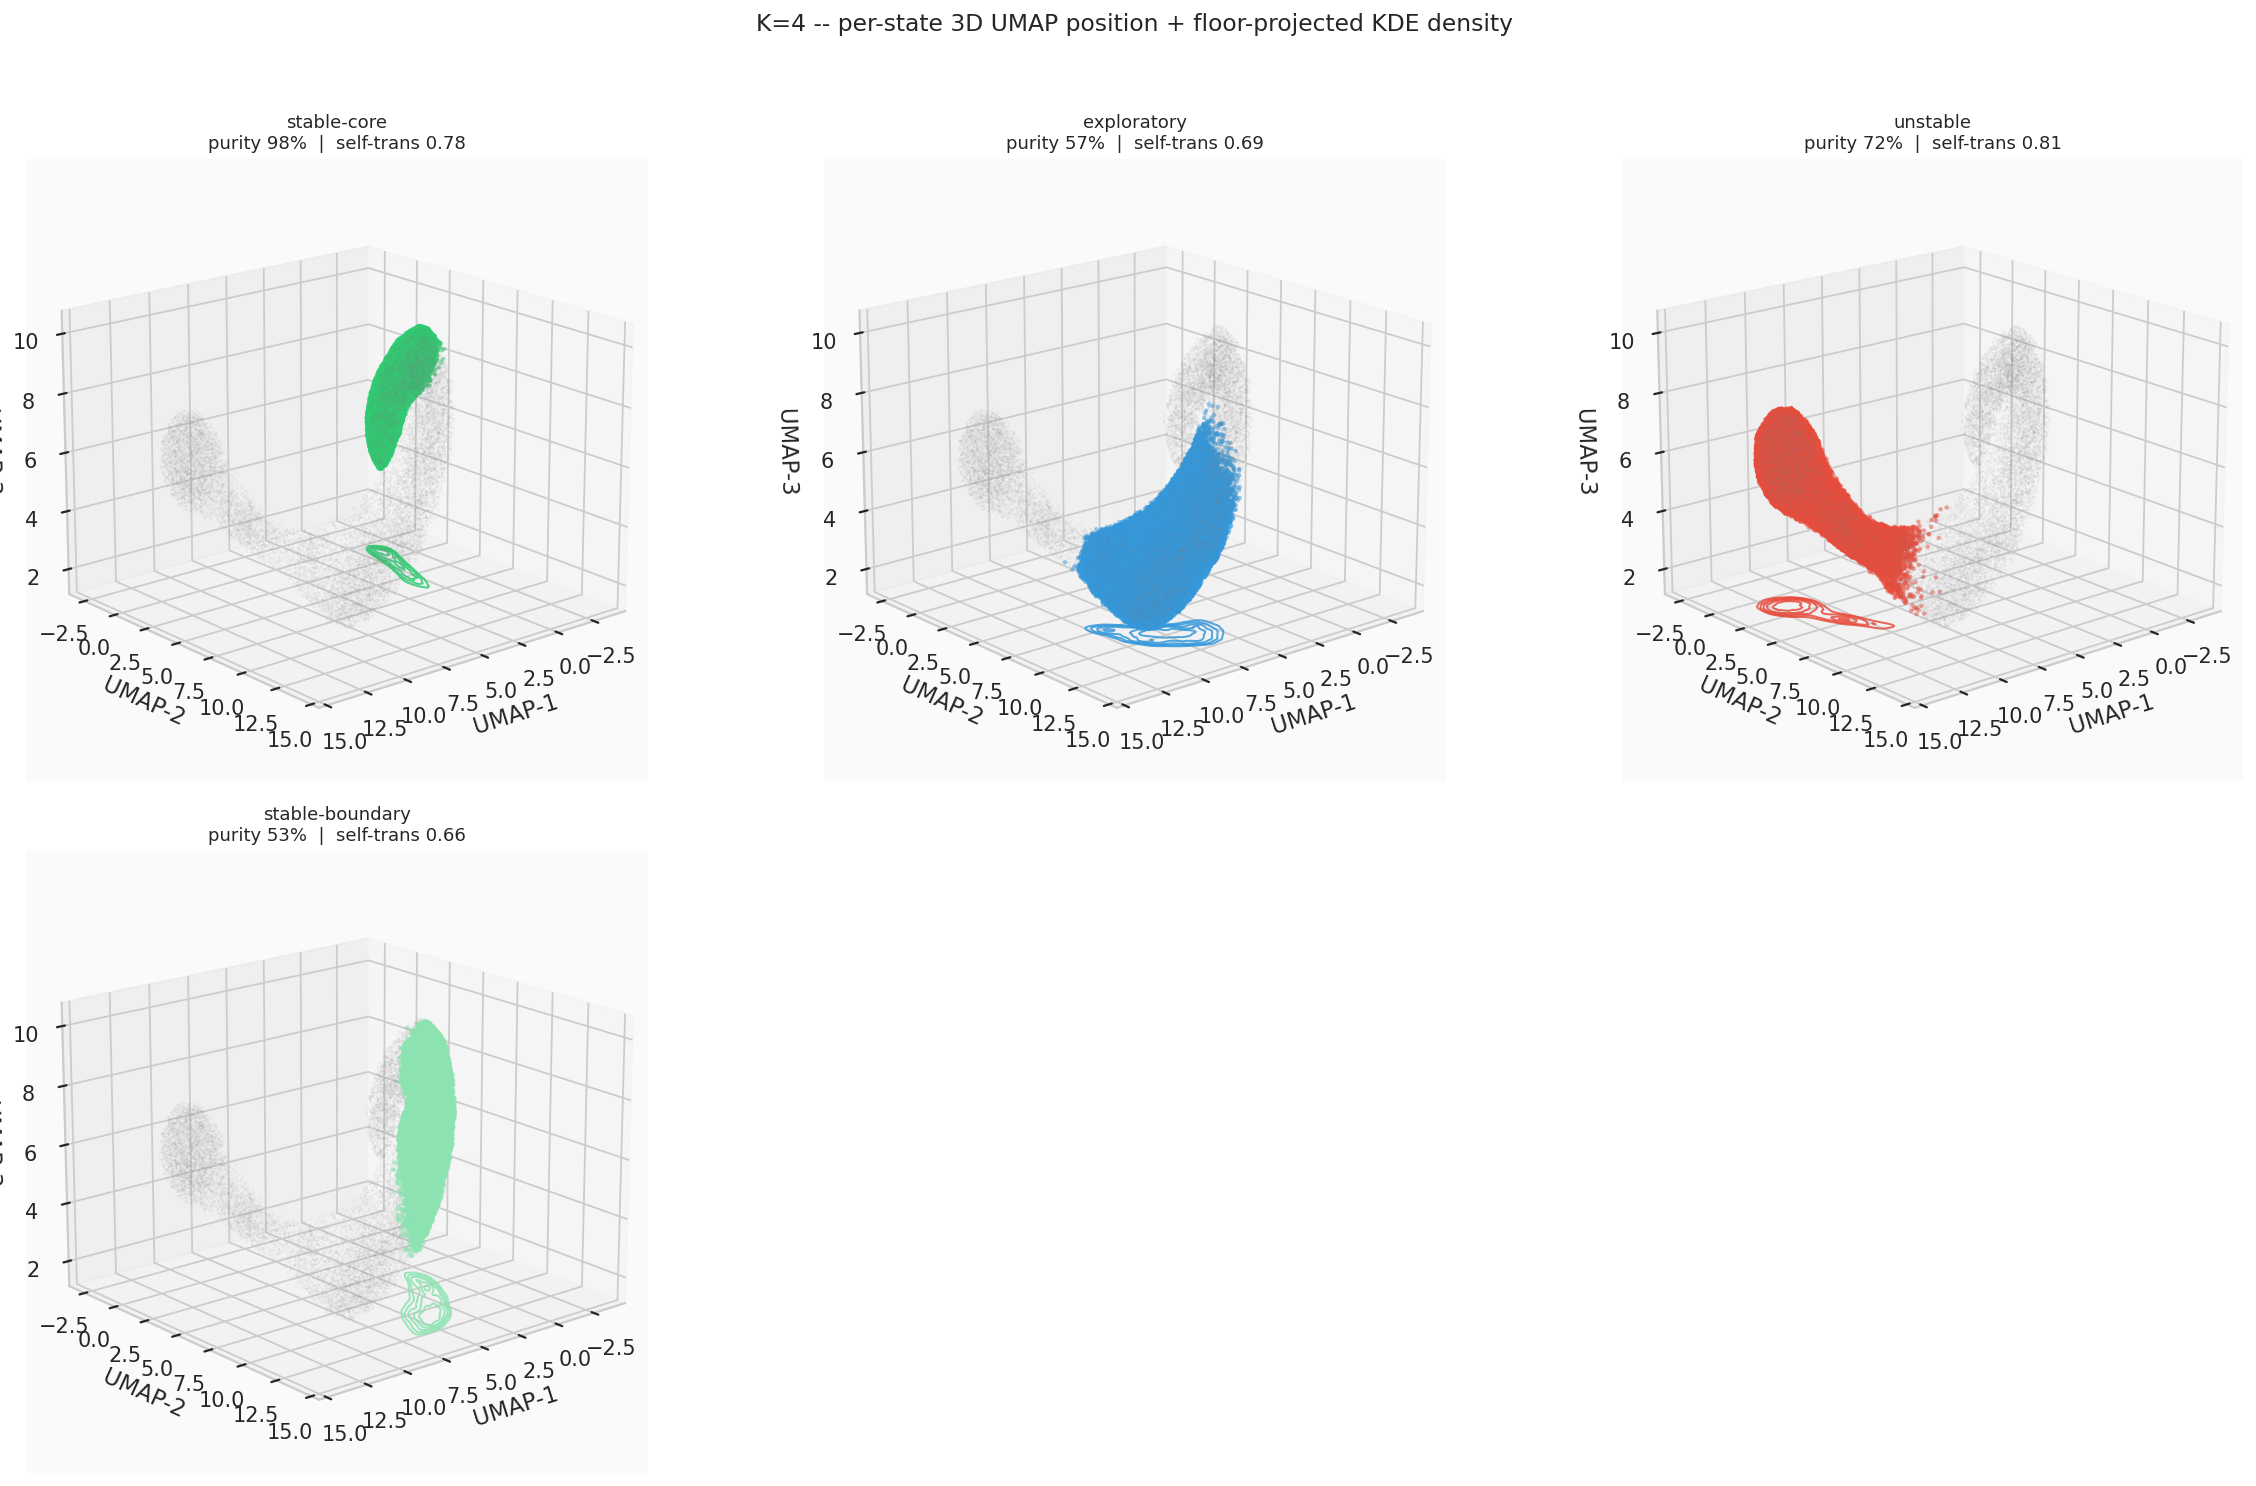

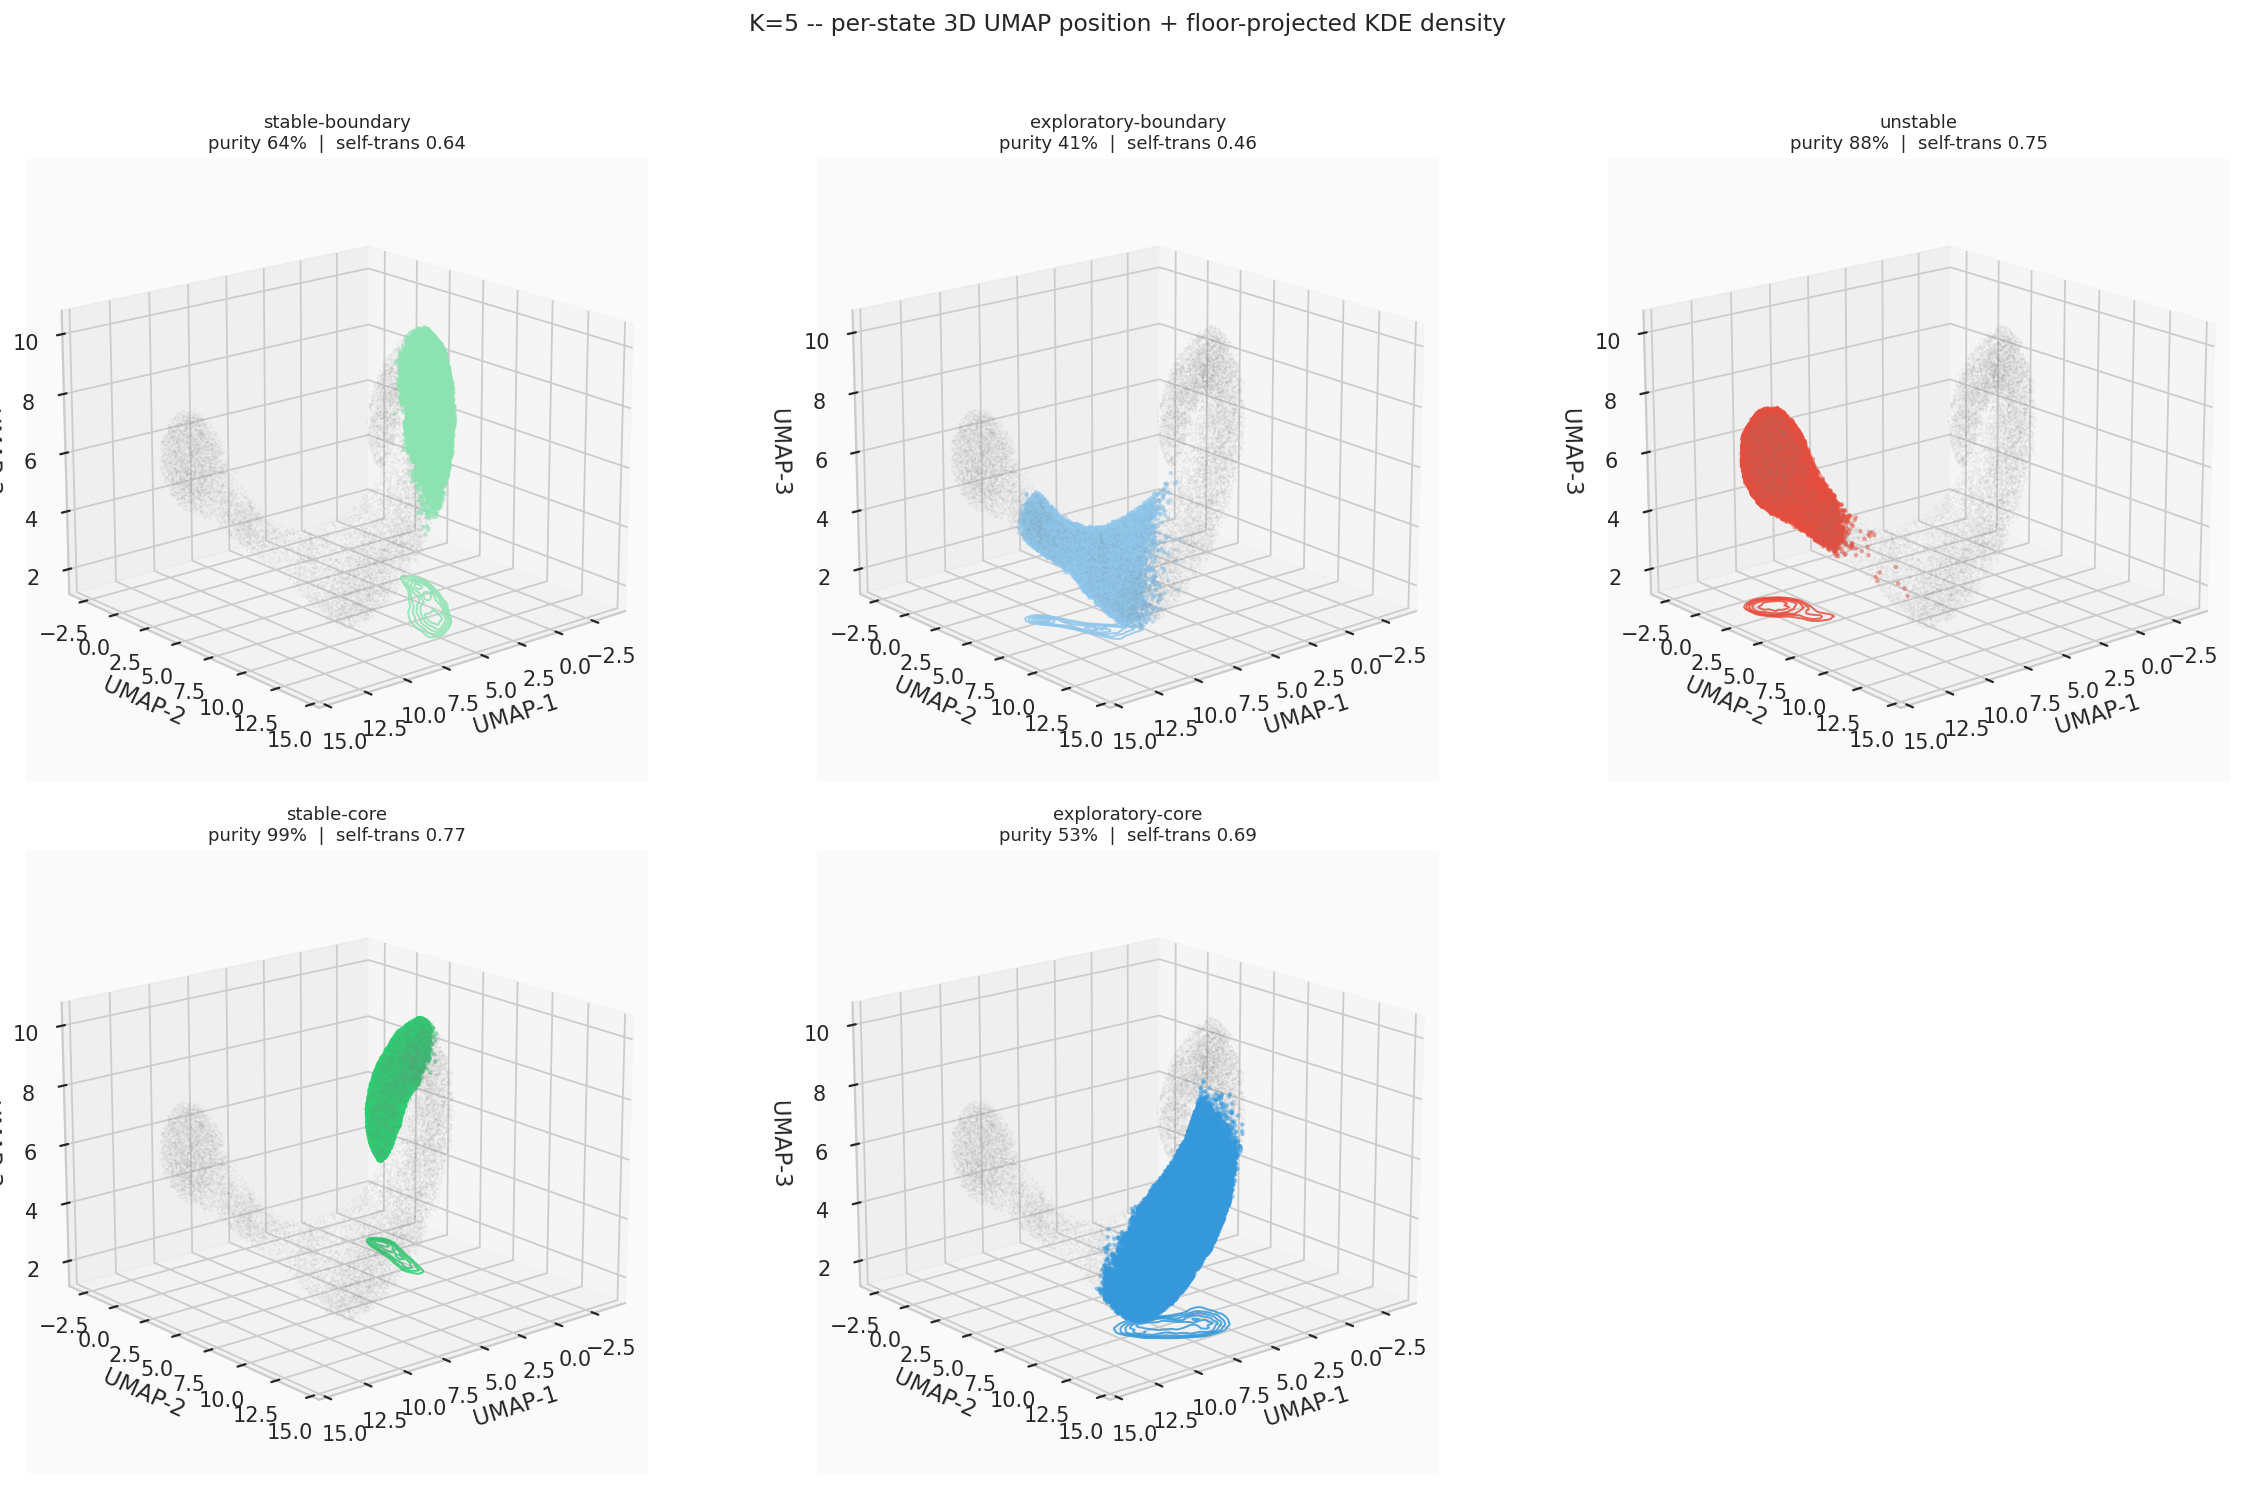

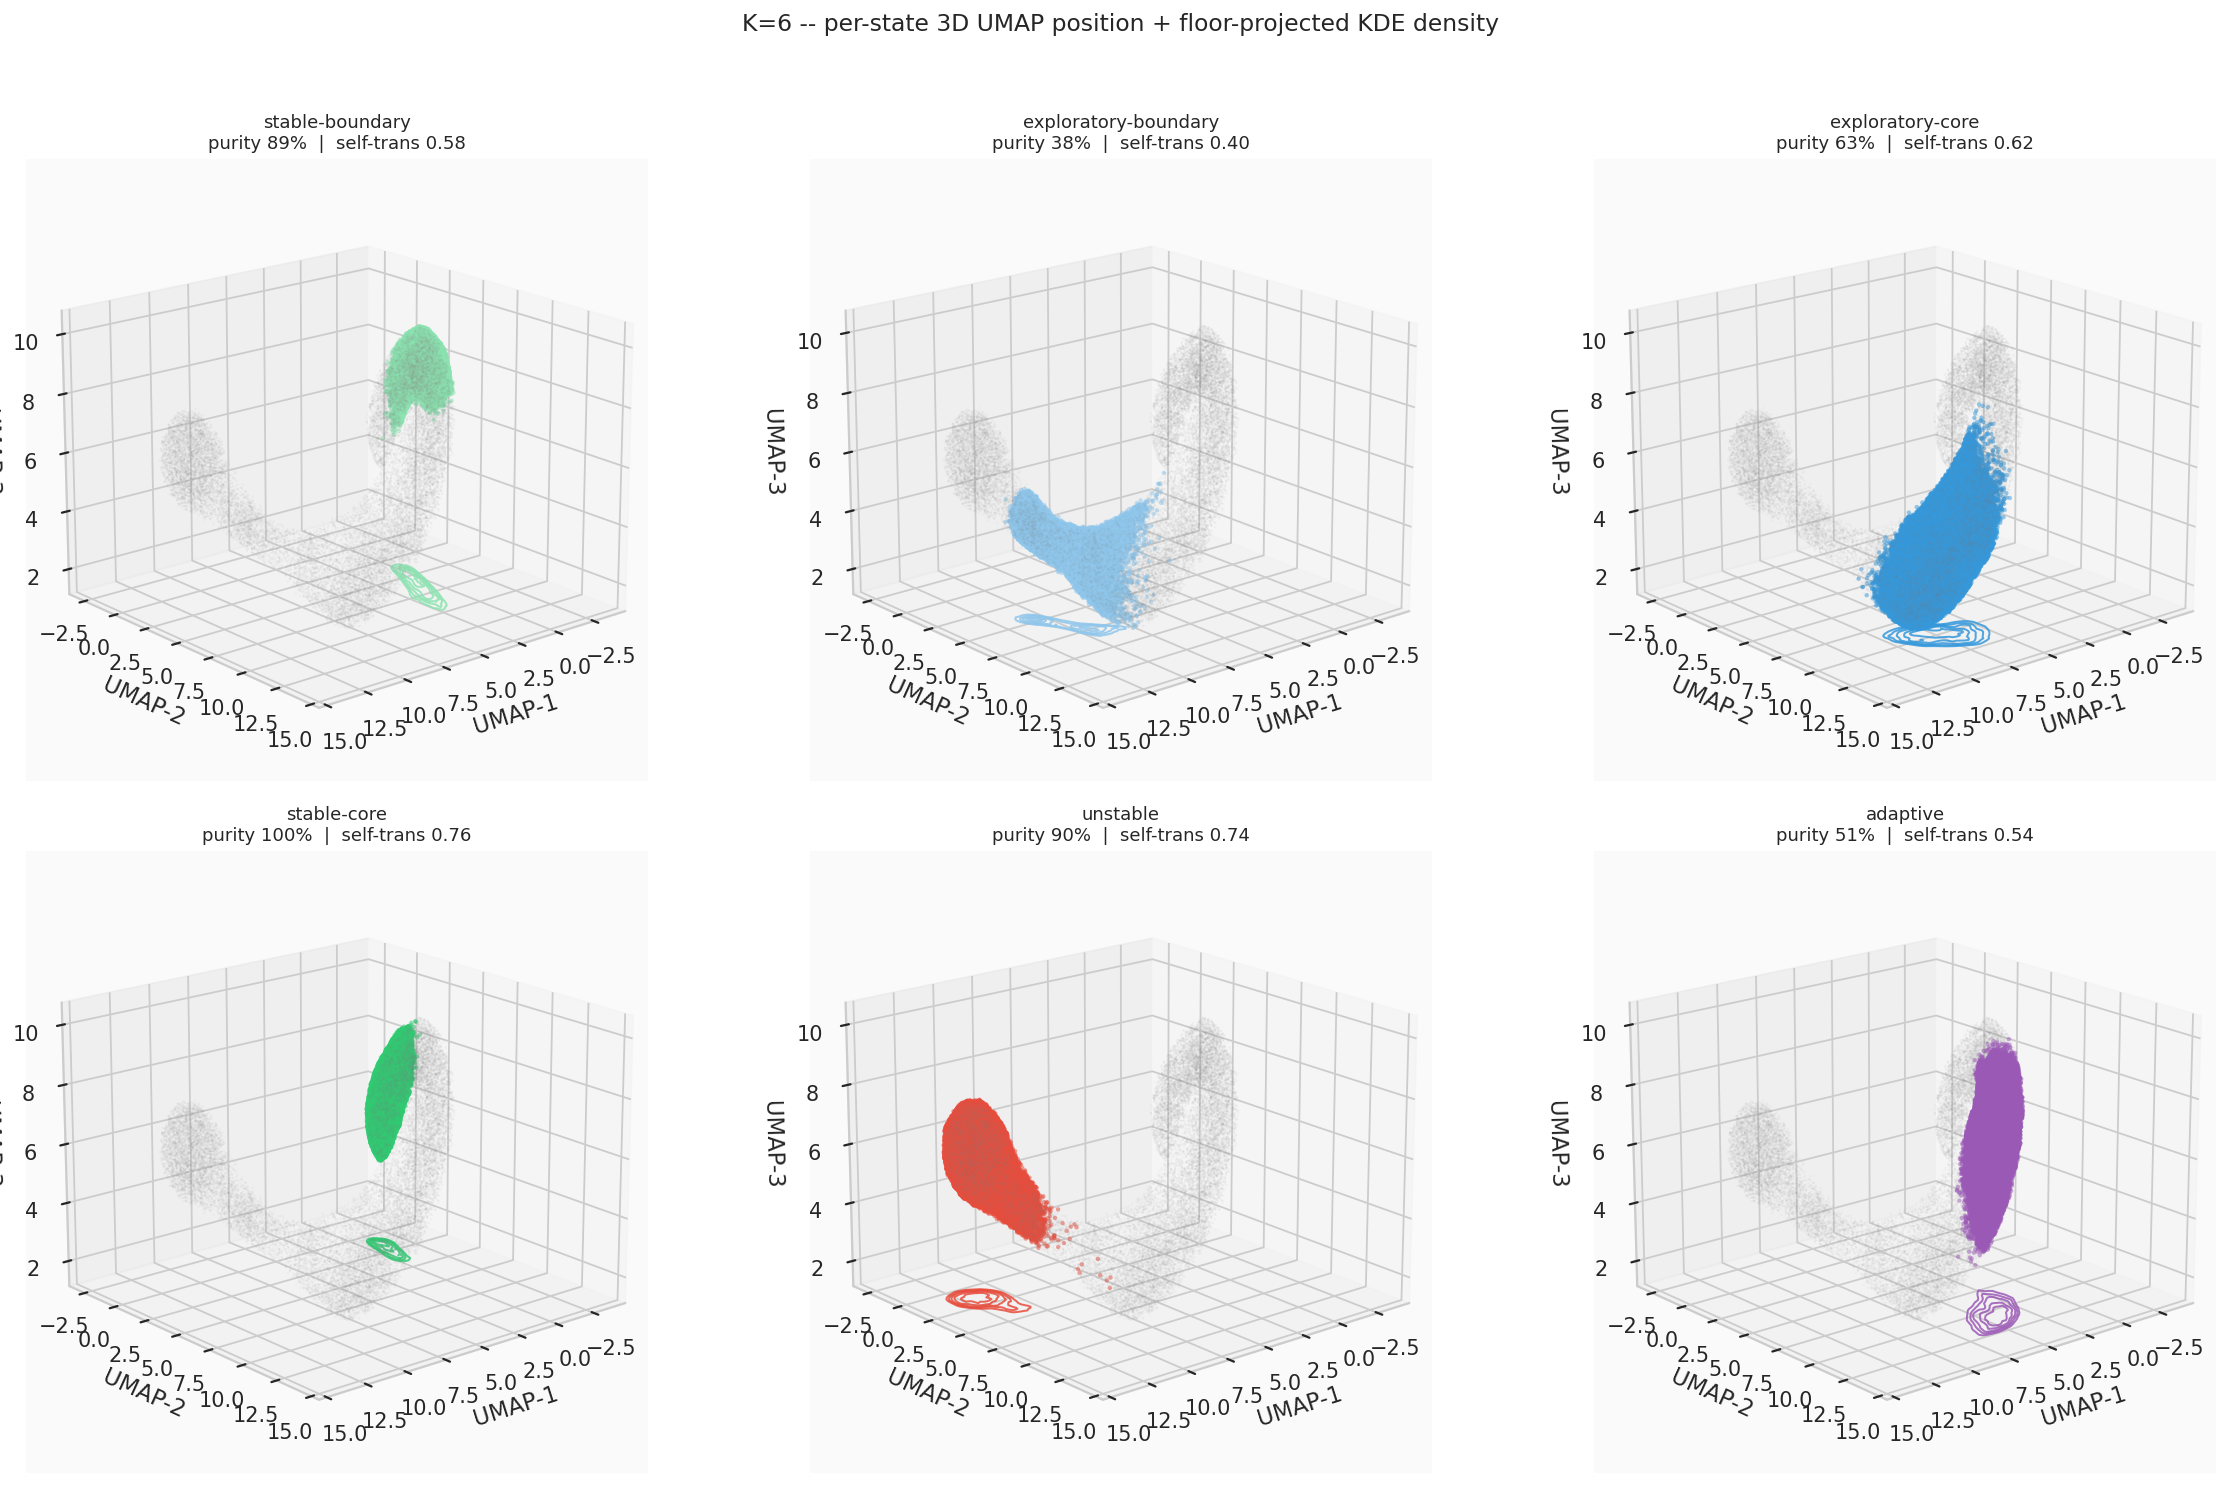

In [19]:
for K in (4, 5, 6):
    _, pred_sid = state_predictions_sid[K]
    sub_df = state_id_df[state_id_df["K"] == K].set_index("state")
    labels = state_labels_by_K[K]

    z_floor = umap3d_sid[:, 2].min() - 0.3

    n_cols = 3
    n_rows = -(-K // n_cols)
    fig = plt.figure(figsize=(6.2 * n_cols, 5.6 * n_rows))

    for state in range(K):
        ax = fig.add_subplot(n_rows, n_cols, state + 1, projection="3d")
        name, color = labels[state]
        purity, self_t, n_obs = sub_df.loc[state, ["purity", "self_transition", "n_obs"]]

        ax.scatter(umap3d_sid[sub_idx, 0], umap3d_sid[sub_idx, 1], umap3d_sid[sub_idx, 2],
                   s=1.5, alpha=0.06, color="#888888", linewidths=0)

        pts = umap3d_sid[pred_sid == state]
        ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=6, alpha=0.5, color=color, linewidths=0)

        xx, yy, zz = kde_density_grid(pts[:, :2], grid_resolution=100, bw_method=0.15,
                                       grid_bounds=grid_bounds_2d)
        # Levels start above 0 for the same reason as the 2D panels above: a
        # near-zero level traces the KDE's far-field tail across the whole grid.
        ax.contour(xx, yy, zz, zdir="z", offset=z_floor,
                   levels=np.linspace(0.18 * zz.max(), zz.max(), 6),
                   colors=[color], linewidths=1.1, alpha=0.85)

        ax.set_title(f"{name}\npurity {purity:.0%}  |  self-trans {self_t:.2f}", fontsize=10)
        ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2"); ax.set_zlabel("UMAP-3")
        ax.set_zlim(bottom=z_floor)
        ax.view_init(elev=18, azim=50)

    fig.suptitle(f"K={K} -- per-state 3D UMAP position + floor-projected KDE density",
                 fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(figfile(f"fig_nb07_05_state_identity_3d_K{K}.png"), dpi=150, bbox_inches="tight")
    plt.show()


### Self-transition persistence, by state

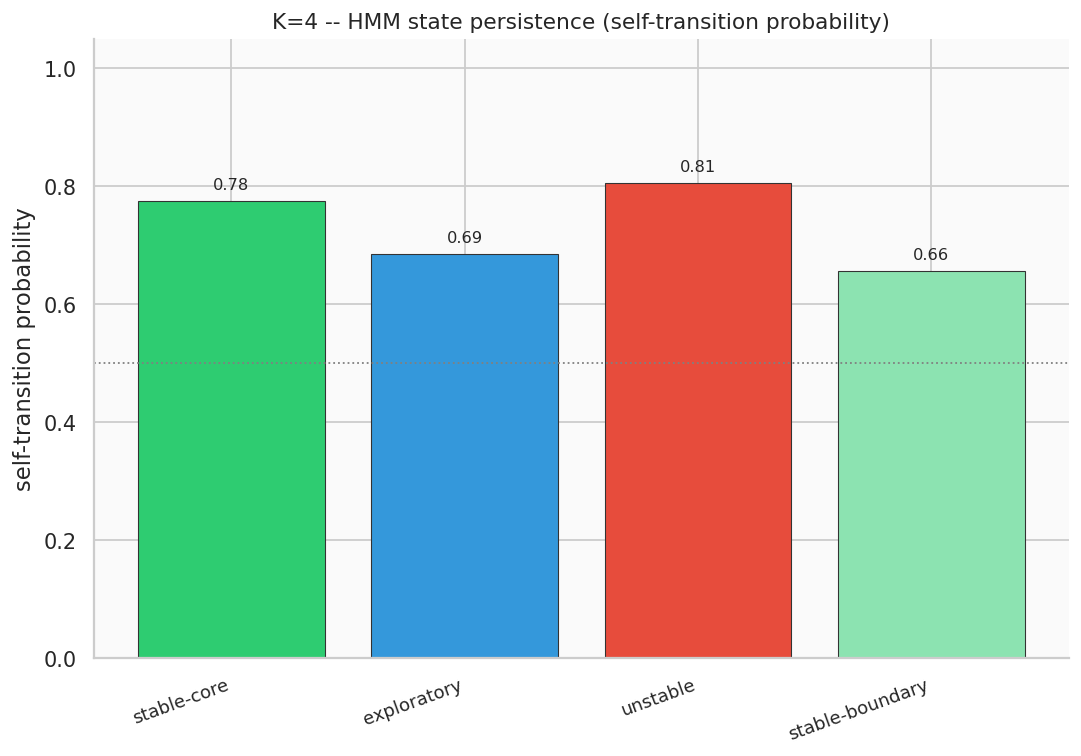

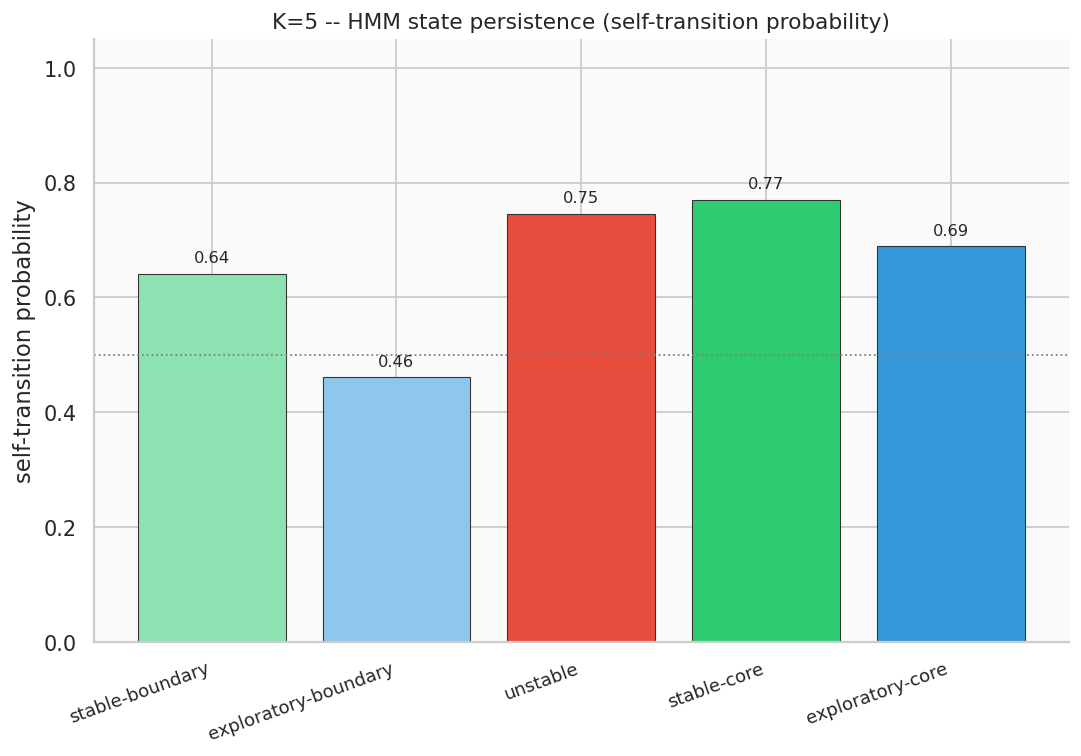

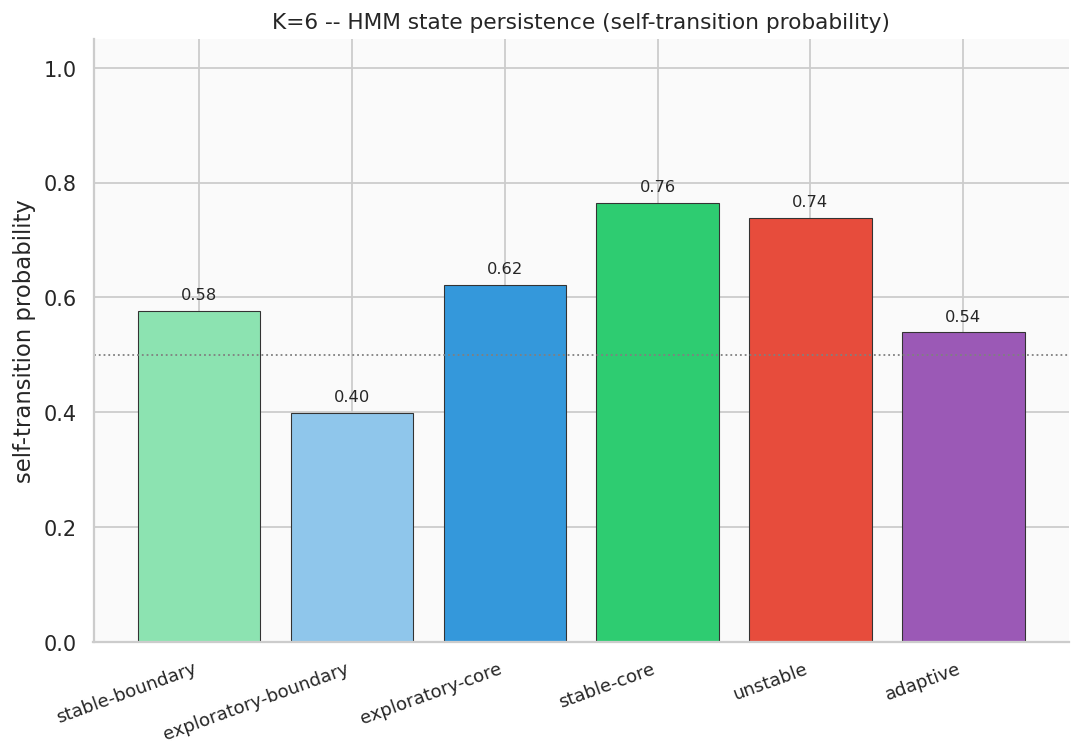

In [20]:
for K in (4, 5, 6):
    sub_df = state_id_df[state_id_df["K"] == K].set_index("state")
    labels = state_labels_by_K[K]

    fig, ax = plt.subplots(figsize=(8.5, 6))
    states = sorted(labels.keys())
    colors = [labels[s][1] for s in states]
    bar_names = [labels[s][0] for s in states]
    bars = ax.bar(range(len(states)), sub_df.loc[states, "self_transition"], color=colors,
                  edgecolor="#333333", linewidth=0.6)
    for i, s in enumerate(states):
        ax.text(i, sub_df.loc[s, "self_transition"] + 0.02, f"{sub_df.loc[s,'self_transition']:.2f}",
                ha="center", fontsize=9)
    ax.set_xticks(range(len(states))); ax.set_xticklabels(bar_names, fontsize=10, rotation=20, ha="right")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("self-transition probability")
    ax.set_title(f"K={K} -- HMM state persistence (self-transition probability)", fontsize=12)
    ax.axhline(0.5, color="gray", ls=":", lw=1)
    plt.tight_layout()
    plt.savefig(figfile(f"fig_nb07_06_state_persistence_K{K}.png"), dpi=150, bbox_inches="tight")
    plt.show()


**Result.** `unstable` is captured by exactly one state at every K tested (4,
5, 6), with purity rising monotonically (72% -> 88% -> 90%) and consistently high self-transition
(0.81/0.75/0.74) -- it never splits into a core+boundary pair. The state count decomposes cleanly
by regime at each K, and the two regimes that split do so at *different* K, not both at once:

- **K=4** (4 states): `stable` x 2 (`stable-core` purity 97.9%, self-transition 0.78;
  `stable-boundary` purity 52.8%, self-transition 0.66) + `exploratory` x 1 (57.3% purity) +
  `unstable` x 1 (72.3%) + `adaptive` x 0. Even at the textbook-correct K=4, states are not
  allocated one-per-regime.
- **K=5** (5 states): the extra state over K=4 goes to splitting `exploratory`, not to a new
  regime -- `stable` x 2 (core sharpens to 98.7%) + `exploratory` x 2 (`exploratory-core` 52.8%,
  `exploratory-boundary` 41.4%) + `unstable` x 1 (88.5%) + `adaptive` x 0.
- **K=6** (6 states): the extra state over K=5 is the first (and only) one to touch `adaptive` --
  `stable` x 2 (core 99.8%) + `exploratory` x 2 (core 62.6%, boundary 38.1%, self-transition
  0.40 -- the least-persistent state observed at any K) + `unstable` x 1 (90.4%) + `adaptive` x 1,
  but at only 51.3% purity -- barely above chance and the lowest purity of any state in the table.

**Replication check.** This is the same qualitative pattern found at N=50,T=2,000 in the earlier,
compute-budget-reduced pass through this notebook, with purities matching within ~2 percentage
points throughout (e.g. `stable-core` 97.9%->97.9%, `unstable` 71.9%->72.3%, `adaptive`
50.8%->51.3%) despite 2.5x the observations. The mechanism is not a small-sample artefact.

**Conclusion.** The extra states BIC selects at K=5 and K=6 are not new behavioral regimes. The
mismatch starts at the ground-truth K=4 itself, where `stable` already needs two states; the
fifth state (K=5) goes to giving `exploratory` the same core+boundary treatment; the sixth state
(K=6) is the only one that goes toward `adaptive` at all, and even then only weakly. `unstable`
is the sole regime that never needs more than one state, matching NB02's finding that it sits
apart from the other three regimes' shared manifold. **This diagnostic was not extended to K=7 or
K=8** -- \S6 shows the full grid's BIC-optimal K is now typically 7 or 8, not 5 or 6, once the
tested range is widened to K=2..8, so this K=4-6 mechanism does not by itself explain the two
further states BIC actually selects at full scale. The established core+boundary-splitting
mechanism is the best-supported hypothesis for those further states too, but which regime(s)
specifically absorb the K=7/K=8 splits is not directly verified here and is flagged as follow-up
work (\S13), not silently assumed.

## 9. Evidence Checklist for Robustness Analysis

In [21]:
print("ROBUSTNESS & FINAL EXPERIMENT ANALYSIS -- EVIDENCE CHECKLIST (NB07)")
print("=" * 70)

# C1: full covariance improves accuracy over diagonal on the reliable subset
mean_acc_full_rel = reliable_df["accuracy_full"].mean()
mean_acc_diag_rel = reliable_df["accuracy_diag"].mean()
c1_pass = mean_acc_full_rel > mean_acc_diag_rel
print(f"\nC1 -- Full covariance improves Viterbi accuracy over diagonal (reliable subset)")
print(f"     Full: {mean_acc_full_rel:.3f}  Diagonal: {mean_acc_diag_rel:.3f}")
print(f"     {'PASS' if c1_pass else 'FAIL'}")

# C2: BIC recovers K=4 for large N*T (reliable-region) configs
large_bic = results_df[results_df["total_obs"] >= 20000]
c2_pass = (large_bic["bic_opt_k_full"] == 4).mean() > 0.5
print(f"\nC2 -- Full-covariance BIC recovers ground-truth K=4 for N*T >= 20,000")
print(f"     {(large_bic['bic_opt_k_full']==4).mean()*100:.0f}% of large configs select K=4 "
      f"(diagonal, for reference: {(large_bic['bic_opt_k_diag']==4).mean()*100:.0f}%)")
print(f"     {'PASS' if c2_pass else 'FAIL'}")

# C3: stationary distribution MAE is reasonable on the reliable subset
c3_pass = mae_df["mae_diag"].mean() < 0.15
print(f"\nC3 -- Stationary distribution MAE is reasonable (reliable subset)")
print(f"     Mean MAE: {mae_df['mae_diag'].mean():.4f}  (threshold: <0.15; NB03 reference: 0.102)")
print(f"     {'PASS' if c3_pass else 'FAIL'}")

# C4: mitigation stack correctly flags risky configs (fallback/warning rate
# should be higher in the HIGH/MEDIUM risk region than the LOW/NEGLIGIBLE region)
high_risk = results_df[results_df["total_obs"] < 5000]
low_risk  = results_df[results_df["total_obs"] >= 20000]
c4_pass = high_risk["reliable"].mean() <= low_risk["reliable"].mean()
print(f"\nC4 -- Mitigation stack correctly discriminates risk by configuration size")
print(f"     Reliable rate, HIGH-risk region (N*T<5,000): {high_risk['reliable'].mean()*100:.0f}%")
print(f"     Reliable rate, LOW-risk region (N*T>=20,000): {low_risk['reliable'].mean()*100:.0f}%")
print(f"     {'PASS' if c4_pass else 'FAIL'}")

# C5: no undetected state collapse on the reliable subset (by construction,
# reliable==True already excludes state_collapse -- this checks the flag logic itself)
c5_pass = not reliable_df["state_collapse"].any()
print(f"\nC5 -- No undetected state collapse on the reliable subset")
print(f"     State collapse cases in reliable subset: {reliable_df['state_collapse'].sum()}")
print(f"     {'PASS' if c5_pass else 'FAIL'}")

# C6: full covariance does not underperform diagonal by >0.05 ARI on the reliable subset (A10)
c6_pass = not reliable_df['flagged_worse_than_diag'].any() if 'flagged_worse_than_diag' in reliable_df else not results_df.loc[results_df['reliable'],'flagged_worse_than_diag'].any()
n_flagged_reliable = results_df.loc[results_df['reliable'], 'flagged_worse_than_diag'].sum()
print(f"\nC6 -- Full covariance does not underperform diagonal by >0.05 ARI (reliable subset, A10)")
print(f"     Flagged configs in reliable subset: {n_flagged_reliable}")
print(f"     {'PASS' if c6_pass else 'FAIL'}")

results_all = [c1_pass, c2_pass, c3_pass, c4_pass, c5_pass, c6_pass]
print()
print("=" * 70)
print(f"Overall: {sum(results_all)}/6 criteria satisfied")
print("=" * 70)


ROBUSTNESS & FINAL EXPERIMENT ANALYSIS -- EVIDENCE CHECKLIST (NB07)

C1 -- Full covariance improves Viterbi accuracy over diagonal (reliable subset)
     Full: 0.655  Diagonal: 0.642
     PASS

C2 -- Full-covariance BIC recovers ground-truth K=4 for N*T >= 20,000
     0% of large configs select K=4 (diagonal, for reference: 0%)
     FAIL

C3 -- Stationary distribution MAE is reasonable (reliable subset)
     Mean MAE: 0.0852  (threshold: <0.15; NB03 reference: 0.102)
     PASS

C4 -- Mitigation stack correctly discriminates risk by configuration size
     Reliable rate, HIGH-risk region (N*T<5,000): 100%
     Reliable rate, LOW-risk region (N*T>=20,000): 100%
     PASS

C5 -- No undetected state collapse on the reliable subset
     State collapse cases in reliable subset: 0
     PASS

C6 -- Full covariance does not underperform diagonal by >0.05 ARI (reliable subset, A10)
     Flagged configs in reliable subset: 0
     PASS

Overall: 5/6 criteria satisfied


### Notebook 07 Findings

| Finding | Evidence |
|---------|----------|
| Mitigation stack works: full covariance runs reliably across the whole grid, including the issue document's HIGH-risk corner | C3/C4/C5 all PASS; 160/160 configurations reliable (no fallback, no state collapse) -- the numerical-instability risk `LBSM-ISSUE-NB07-001` warned about did not materialise anywhere in the full 4,800-fit grid, most likely because the mitigation stack (regularisation, restarts, KMeans warm start) is doing exactly what it was designed to do. One narrower failure mode did occur and was caught, not silently dropped: at N=5,T=500,seed=46 (the smallest configuration), the *diagonal*-covariance BIC sweep (`min_covar=1e-3`, no restart protection) diverged for the higher K values in the K=2..8 range (`startprob_ must sum to 1 (got nan)`) -- recorded as `diag_bic_failed=True` with that one cell's `bic_opt_k_diag` left as missing rather than crashing the worker or being silently imputed. |
| Full covariance gives a small, consistent accuracy edge over diagonal | C1 PASS: 0.655 vs. 0.642 mean Viterbi accuracy on the reliable subset (mean ARI delta +0.0072, 0/160 configurations flagged as a >0.05 ARI regression) -- real but modest, not the dramatic improvement the issue document's "Expected Outcomes" table projected (toward 70.4%) |
| **BIC does not recover K=4 under either covariance type, at any of the 160 grid configurations tested -- and widening the search range reveals the over-selection is worse than the reduced-scope grid suggested** | C2 FAIL: with the model-order search extended to K=2..8 (was K=2..6), diagonal covariance now selects K=7 or K=8 almost everywhere (mode across seeds), and full covariance ranges from K=6 at the smallest configurations up to K=8 at the largest -- including N=50,T=5,000 (250,000 observations, the largest configuration in the full grid), where **both** covariance types select K=8, the edge of the tested range. This is not a small, bounded overselection (K=5 or 6, "close to" the true K=4) as the earlier reduced-scope grid suggested -- it is a preference for *more* components that keeps climbing as more are offered, and K=8 was never confirmed as a plateau. Since full covariance can represent the correlated-feature geometry diagonal covariance cannot, and the failure persists (and grows) identically under both, covariance misspecification remains **ruled out** as the explanation. |
| **The AR-1 temporal-autocorrelation hypothesis is a real but partial contributor, not the primary cause** | A follow-up test (\S8b) monkey-patched every regime's `autocorr` to `0.0` and re-ran the BIC sweep at N=50,T=5,000 (the grid's actual largest configuration). Unpatched, this configuration selects K=8 under both covariance types. With autocorrelation removed: diagonal drops only slightly, to K=7; full covariance drops more substantially, to K=5 -- a real, non-trivial reduction, concentrated in the covariance type that can actually represent the resulting cross-feature structure, but still short of the ground-truth K=4. AR-1 autocorrelation is therefore not the primary driver of the over-selection, and does not act identically across covariance types, but it is not inert either -- a more nuanced result than the earlier reduced-scope grid's apparent "no effect" finding (K unchanged there), which was itself an artefact of the narrower K=2..6 search range never letting the diagnostic register a movement from K=6 down to K=5. |
| **Representation-space transformation does not resolve the overselection either, and also hits the same K=8 ceiling** | \S8c re-ran the BIC sweep on UMAP-embedded coordinates (2-D and 3-D, both covariance types) instead of the raw 6-D features, at N=50,T=5,000. K=4 recovered in 0/4 configurations tested -- BIC selects K=8 in every UMAP-space variant too, identical to the raw-feature-space result at this configuration. Embedding into the previously validated nonlinear manifold coordinates does not linearise the regime boundaries enough to fix this. |
| **The curved-manifold hypothesis is confirmed as a mechanism, not left as a correlated guess -- and it replicates at 2.5x the sample size** | \S8d fit diagonal HMMs directly at K=4/5/6 (at N=50,T=5,000) and read off which ground-truth regime each learned state captures and how persistently agents stay in it. K=4 = `stable`x2 (`stable-core` 97.9%, `stable-boundary` 52.8%) + `exploratory`x1 (57.3%) + `unstable`x1 (72.3%) + `adaptive`x0 -- states are not allocated 1:1 with regimes even at the textbook-correct K=4. K=5's extra state splits `exploratory` (core 52.8%, boundary 41.4%), not a new regime. K=6's extra state is the only one that touches `adaptive` at all, and only weakly (51.3% purity, the lowest in the whole table); `exploratory`'s split sharpens further (boundary self-transition 0.40 -- the least-persistent state observed at any K). `unstable` never splits at any K. These numbers match the earlier N=50,T=2,000 run within ~2 percentage points throughout, confirming the mechanism is not a small-sample artefact. **Not independently verified**: whether this same core+boundary mechanism continues to explain the K=7/K=8 states the full grid actually selects (\S13). |
| Full covariance does not underperform diagonal anywhere reliable | C6 PASS: 0/160 flagged configurations |
| Stationary distribution recovery is reasonable and comparable to the earlier reduced-scope grid | C3 PASS: mean MAE 0.0852 across the full 160-configuration reliable subset vs. NB03's single-config 0.102 and the reduced-scope grid's 0.0838 -- consistent across scale |


## 10. Significance for the TMLR Paper

NB07 contributes to Paper \S6.2/\S9 (Robustness) in four ways:

1. **NB03's open BIC-elbow failure does not resolve under full covariance -- and at full scale
   (the complete `LBSM-ISSUE-NB07-001` protocol: 160 configurations, 4,800 full-covariance fits,
   K=2..8) the failure is worse than the earlier reduced-scope grid suggested.** Diagonal
   covariance now selects K=7 or K=8 almost everywhere; full covariance ranges K=6-8, reaching
   K=8 -- the edge of the tested range -- at the largest, most-reliable configurations. The paper
   should not describe this as a bounded "K=5 or 6" overselection: on this evidence, BIC's
   preference for more components had not plateaued by K=8, and whether it would at K=9+ is not
   established. Covariance misspecification remains ruled out as the explanation (full covariance
   fails identically to diagonal, and no better).
2. **Three further hypotheses were tested for the over-selection; two are cleanly ruled out, one
   is a real but partial contributor, and the curved-manifold mechanism is confirmed directly and
   shown to replicate across a 2.5x change in sample size.** Representation-space transformation
   into the previously validated UMAP embedding (\S8c) is cleanly ruled out (same K=8 ceiling as
   raw-feature space). AR-1 temporal autocorrelation (\S8b) is *not* cleanly ruled out at full
   scale: removing it drops full-covariance's BIC-optimal K from 8 to 5 at the grid's largest
   configuration -- a real, substantial effect, though still short of K=4, and much smaller for
   diagonal covariance (8 to 7). The state-identity diagnostic (\S8d) confirms the remaining
   curved-manifold mechanism directly rather than by correlation, at K=4/5/6: at the ground-truth
   **K=4 itself**, `stable` already occupies two states (a high-purity "core" plus a lower-purity
   "boundary"), `exploratory` and `unstable` get one state each, and `adaptive` gets none; K=5's
   extra state splits `exploratory` the same way; K=6's extra state is the only one that touches
   `adaptive`, and only weakly. These exact numbers reproduce within ~2 percentage points at
   N=50,T=5,000 versus the earlier N=50,T=2,000 pass, despite 2.5x the data -- not a small-sample
   artefact. **Not established**: whether this same mechanism explains the further states BIC
   selects at K=7/K=8, which this diagnostic was not extended to cover.
3. **A documented, executed, full-scale robustness grid** -- the complete, un-reduced
   `LBSM-ISSUE-NB07-001` protocol (160 configurations, 10 seeds, 10 restarts x 3 `min_covar`
   values, 4,800 full-covariance fits) with an honest reliable/unreliable split and a full
   per-attempt audit trail (`full_scale_attempt_log.csv`, 4,800 rows -- every attempt, including
   discarded/failed ones, not only the winners), following the issue document's "prevent-the-fit
   is the wrong call" design principle throughout, including for the one genuine failure
   encountered (the diagonal BIC sweep divergence at N=5,T=500,seed=46, caught and recorded rather
   than silently dropped or allowed to crash the worker).
4. **A reusable robust-fitting infrastructure** (`src/hmm/robust_fitting.py`, including the
   `collect_attempt_log` mechanism added for this run) for any future full-covariance work in this
   line of research, addressing a general failure mode (ill-conditioning under small effective
   per-state sample size) rather than a one-off fix.

## 11. Export Artefacts

\noindent Paths relative to the repository root.

- `data/processed/nb07/robustness_grid_results.csv` -- full per-configuration results (160 rows,
  every field from `LBSM-ISSUE-NB07-001` \S6's recording protocol, plus `unstable_recall_full`,
  `n_iter_full`, `diag_fit_failed`, `diag_bic_failed`)
- `data/processed/nb07/full_scale_attempt_log.csv` -- full per-attempt audit trail (4,800 rows:
  every `min_covar` x restart attempt, not only the winner, including failed/discarded ones)
- `data/processed/nb07/grid_vs_reliable_summary.csv` -- two-row full-grid vs. reliable-subset summary
- `data/processed/nb07/numerical_health_by_config.csv` -- condition number / reliability by (N,T)
- `data/processed/nb07/stationary_distribution_mae.csv` -- per-config stationary-distribution MAE
- `data/processed/nb07/umap_space_bic_recovery.csv` -- \S8c BIC-optimal K, UMAP 2-D/3-D x diag/full
- `data/processed/nb07/hmm_state_identity_diagnostic.csv` -- \S8d per-state dominant regime, purity,
  self-transition probability, at K=4/5/6
- `outputs/figures/nb07/fig_nb07_01_full_vs_diag_ari.png`
- `outputs/figures/nb07/fig_nb07_02_bic_elbow_comparison.png`
- `outputs/figures/nb07/fig_nb07_03_numerical_health_grid.png`
- `outputs/figures/nb07/fig_nb07_04_state_identity_2d_K{4,5,6}.png` -- HMM states over the 2-D
  UMAP manifold, one figure per K, semantic core/boundary labeling
- `outputs/figures/nb07/fig_nb07_05_state_identity_3d_K{4,5,6}.png` -- same, over the 3-D UMAP
  manifold
- `outputs/figures/nb07/fig_nb07_06_state_persistence_K{4,5,6}.png` -- per-state self-transition
  probability, one figure per K

## 12. Next Steps

1. **Extend the BIC search range past K=8.** \S6/\S8c show BIC-optimal K reaching the K=2..8
   ceiling tested here at the grid's larger configurations, under both raw-feature and UMAP-space
   representations -- this notebook cannot distinguish a genuine plateau at K=8 from a preference
   that keeps climbing. The single highest-value follow-up given \S6's result.
2. **Extend the \S8d state-identity diagnostic to K=7 and K=8** to check whether the established
   core+boundary-splitting mechanism (confirmed at K=4-6, replicated across a 2.5x change in
   sample size) continues to explain the further states BIC actually selects at full scale, or
   whether a different phenomenon takes over once `unstable` and `adaptive` are also fully
   represented.
3. **Test whether a non-Gaussian or mixture-of-Gaussians emission model per state recovers K=4
   directly**, now that \S8d has identified *which* regimes need the extra components (`stable`,
   `exploratory`) and *why* (core+boundary structure on a curved manifold) -- the natural
   modelling follow-up now that the mechanism is confirmed rather than hypothesised.
4. **Extend the robustness grid to the RL layer**, per NB05's own "Next Steps": does the trained
   (greedy) policy consistently beat the random-policy baseline across all N/T configurations, not
   just the single N=20,T=2000 configuration NB05 tested.
5. **Paper \S6.2/\S9.** Report the full 160-configuration grid's numbers, not the earlier
   reduced-scope pass; report the BIC non-recovery result as a genuine, tested negative finding
   that *worsens* under a wider K search rather than staying bounded near K=4 -- covariance
   misspecification and representation-space transformation are both cleanly ruled out, AR-1
   autocorrelation is a real but partial and covariance-type-dependent contributor, and the
   curved-manifold core+boundary splitting mechanism (\S8d) is confirmed directly and shown to
   replicate across sample size, with its extension to K=7/K=8 flagged as open follow-up work
   rather than assumed.


## Appendix: Computational Environment

In [22]:
import sys
print("Python:", sys.version.split()[0])
import numpy, scipy, sklearn, hmmlearn
print("numpy:", numpy.__version__, " scipy:", scipy.__version__,
      " scikit-learn:", sklearn.__version__, " hmmlearn:", hmmlearn.__version__)
print("Grid: N x T x seeds =", len(configs), "configurations")
print("Reliable subset:", len(reliable_df), "/", len(results_df))


Python: 3.13.12
numpy: 2.4.4  scipy: 1.17.1  scikit-learn: 1.8.0  hmmlearn: 0.3.3
Grid: N x T x seeds = 160 configurations
Reliable subset: 160 / 160
